# Memory 2: External Memory, Read/Write Heads, and Emergent Symbols

## The Big Picture

So far in this course, the neural networks we've built store everything in their **weights**. Every fact, every pattern, every association — all mixed together in the same set of parameters. This is like trying to remember every person you've ever met, every fact you've ever learned, and every skill you've ever acquired by writing it all on a *single sheet of paper*, layered on top of each other.

Today we explore a different idea: **external memory** — a separate, structured store that a network can read from and write to, the way you might use a notebook or a phone's contact list. This is a fundamental architectural choice with deep implications for both AI and cognitive science.

Here's what we'll build toward, step by step:


### The Arc of Today's Lab

**Part 1: Key-Value Memory.** We start with the simplest possible memory: a dictionary that maps keys (cues) to values (stored information). We'll implement this with Python, then with vectors and dot products — and discover that when keys are similar, memories interfere.

**Part 2: Similarity and Interference.** We'll build a "memory" that shows *why* memory errors happen — and connect this to word2vec-style embedding spaces. The same math that makes memory useful (similar things retrieve similar results) also makes it fallible (similar things get confused).

**Part 3: Neural Turing Machines.** We'll see how neural networks can learn to use external memory through differentiable **read and write heads** — and simulate what happens when these heads are damaged, reproducing the pattern of Patient H.M.'s amnesia.

**Part 4: Putting External Memory to Work: Emergent Symbols (ESBN).** We'll explore an architecture that separates *what something is* from *what role it plays* — enabling one-shot generalization of abstract rules. Then we'll test whether this inductive bias helps with everything, or only with the tasks it was designed for.

The unifying theme: **how you structure memory determines what you can and can't learn** — and the brain's memory architecture tells us something about what kinds of problems evolution optimized us to solve.


###Remember Marr? Memory at the Algorithmic Level

Today's lab also illustrates a powerful idea in cognitive science: the same **algorithm** can be implemented in very different **substrates**.

David Marr (1982) distinguished three levels of analysis for any information-processing system:

1. **Computational level** — *What's* the system's goal? Preserve information over time.
2. **Algorithmic level** — *How* does it do it? ("Store key-value pairs; retrieve by similarity matching")
3. **Implementational level** — *What's it made of?* (Neurons, transistors, or Python code)


 <b> Dictionaries </b>

You might be familiar with <b> "dictionary" data structures </b> in python. Dictionaries are used to store data in <b> key:value </b> pairs.  Given a key, we can retrieve the associated value from memory.

<b> Key-value retrieval </b> is an *algorithm* that appears at Level 2. The same algorithm is implemented in Python dictionaries, in matrices of vectors, in differentiable neural memories, and — we hypothesize — in the hippocampus. Understanding the algorithm teaches us about all four systems, even though their implementations are different.




### Key-Value Memory in Human Cognition

Before we implement anything, notice that key-value retrieval is everywhere in everyday cognition. Your brain is constantly using *cues* (keys) to retrieve *associated information* (values):

- **Faces → Names.** You see someone's face (key) and retrieve their name (value). The face is the lookup cue; the name is what's stored. Notice that this is *asymmetric* — seeing a face and retrieving a name is much easier than hearing a name and retrieving a face. The key-value binding goes in one direction more easily than the other.

- **Smells → Places and Emotions.** The smell of sunscreen (key) retrieves a specific beach vacation (value). This is Proust's famous madeleine effect — a sensory cue unlocks a rich episodic memory. The key here is low-dimensional (a single smell), but the retrieved value is high-dimensional (a whole scene).

- **Song lyrics → Melody.** You see the words "Happy birthday to you" (key) and the melody plays in your head (value). Interestingly, the reverse works too — humming the melody retrieves the words. This is a case where the association is *bidirectional*.


- **Exam questions.** A professor writes a question (key) and you try to retrieve the answer (value) from what you studied. Studying is the *write* operation; the exam is the *read* operation. If you "blank" on an answer, you have a value stored in memory but the provided key doesn't match well enough to retrieve it.

> ** Discussion Question 1:** In the face → name example, why do you think retrieval is easier in one direction than the other? What does this asymmetry tell us about how the brain stores associations? Would a Python dictionary have this asymmetry?


For example, we can make a simple dictionary of countries and capitals.

In [1]:
capital_dict = {'Belarus': 'Minsk', 'Colombia': 'Bogota', 'Canada': 'Ottawa', 'Haiti': 'Port au Prince'}

In [2]:
list(capital_dict.keys())

['Belarus', 'Colombia', 'Canada', 'Haiti']

In [3]:
list(capital_dict.values())

['Minsk', 'Bogota', 'Ottawa', 'Port au Prince']

Then, we can perform simple memory retrieval

In [7]:
capital_dict['Belarus']

'Minsk'

This is a simple way to organize memory! These data structures are often called "associative memories" or "associative arrays" because the key is <b> associated </b> with the value.


The python-specific example above uses <b>strings </b> as the data type, though we could use other data types.

Neural networks deal specifically with <b> vectors </b> (or matrices, or tensors), which represent information (states of the world, states of mind, such as goals etc.)

We can treat keys and values as two concatenated vectors. These are stored in memory. Then, to retrieve a memory we look for the key stored in memory that is most similar a task-specific key.

In a memory array, what stored vector (or part of a vector) is most similar to the key?

The <b> dot product </b> operation can be used to quantify the similarity between vectors.

For two vectors <b>a </b> and <b>b</b>,


$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^n a_i b_i$.

It is standard to compute the dot product between the generated key and all elements of a memory matrix.



Instead of using python dictionaries, let's make our own matrix.

In [8]:
import numpy as np

#initialize for country code, capital code, and concatenated data code.
country = []
capital = []
data = []

#number of elements in vector
n_features = 50

#number of examples.
S=4

#generate a code for each country.
country = np.random.randint(2, size=(n_features, S))

#generate codes for each capital
capital = np.random.randint(2, size=(n_features, S))

#concatenate them to form the data. Assume this is stored in memory.
#.T transposes
data = np.concatenate([country, capital]).T



In [9]:
#to retrieve a capital from memory, let's start with a random key
key_ = np.random.randint(2, size=(1,n_features*2))

#initialize for results
sim = np.zeros(S)

#compute the dot product of they key with each key stored in memory.
#(there are simpler ways to do this that avoid "for" loops, but for clarity, we use two for loops here)
for j in range(0,S):
     sim[j] = np.dot(key_[0,0:n_features], data[j,0:n_features])

#what would be retrieved?
print('similarity measure by country')
print(sim)
print()


similarity measure by country
[15. 14. 15. 15.]



In [10]:
#which country in memory is most similar to the key?
choice_idx = np.argmax(sim)
print(choice_idx)

this_country = list(capital_dict.keys())[choice_idx]
print('The Country is ' + this_country)

#return the corresponding value
this_capital = list(capital_dict.values())[choice_idx]
print('It''s Capital is ' + this_capital)

0
The Country is Belarus
Its Capital is Minsk


In [12]:
#instead of a random code, choose a country code as the key (column in country)
key_ = country[:,1]

sim = np.zeros(S)

#compute the dot product of each row with each other row.
for j in range(0,S):
    #these are similarities of the key to each country's code.
     sim[j] = np.dot(key_, data[j,0:n_features])

print('similarity by country')
print(sim)
print()

#which index is most similar?
choice_idx = np.argmax(sim)
print(choice_idx)

this_country = list(capital_dict.keys())[choice_idx]
print('The Country is ' + this_country)

#return the corresponding value
this_capital = list(capital_dict.values())[choice_idx]
print('It''s Capital is ' + this_capital)


similarity by country
[12. 27. 16. 14.]

1
The Country is Colombia
Its Capital is Bogota


### Memory at a Party: When Keys Are Too Similar

We've seen key-value retrieval with random binary codes. But real mental representations aren't random — similar things have similar codes. This is both what makes memory *useful* (you can generalize) and what makes it *fallible* (you confuse similar things).

Let's make this concrete with a familiar experience: **meeting people at a party and mixing up who told you what.**

Imagine you attend a party and meet 8 people. Your brain encodes each person as a vector of features — height, hair color, glasses, voice, etc. Each person tells you a "secret" (a piece of information). Later, someone asks you: "What did the tall person with dark hair and glasses tell you?"

How does your mind solve this problem?

The standard algorithm: your memory system computes similarity between that query and all stored person-vectors, and retrieves the secret associated with the best match. If two people had similar features, you might retrieve the wrong person's secret — **source misattribution**, Schacter's fourth sin.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

# ============================================================
# ENCODING PEOPLE AS FEATURE VECTORS
# ============================================================
# Each person is represented by 8 features, scored -1 to +1.
# Think of these as: tall/short, dark/light hair, loud/quiet voice, etc.
#
# This is exactly how word2vec and other embedding models work:
# each entity (word, person, concept) is a point in a high-dimensional
# vector space, and SIMILAR entities are NEARBY in that space.

feature_names = ['tall', 'dark_hair', 'glasses', 'loud_voice',
                 'beard', 'funny', 'formal_clothes', 'young']

# 8 people at the party — each row is a person's feature vector
people = {
    'Alex':    np.array([ 1.0,  1.0,  1.0, -0.5, -1.0,  0.8, -0.5,  1.0]),  # tall, dark, glasses, young
    'Blake':   np.array([ 0.9,  0.8,  0.9, -0.3, -1.0,  0.5, -0.3,  0.8]),  # VERY similar to Alex!
    'Casey':   np.array([-1.0, -0.5, -1.0,  1.0,  1.0, -0.5,  1.0, -0.8]),  # short, loud, bearded, formal
    'Dana':    np.array([ 0.0,  1.0, -1.0,  0.5, -1.0,  1.0, -1.0,  1.0]),  # average height, funny, casual
    'Ellis':   np.array([-0.5, -1.0,  1.0, -1.0,  1.0, -0.5,  1.0, -0.5]),  # quiet, bearded, formal
    'Frankie': np.array([ 1.0, -1.0, -1.0,  1.0, -1.0,  1.0, -1.0,  0.5]),  # tall, blonde, loud, funny
    'Gray':    np.array([-1.0,  0.5,  1.0, -0.5, -1.0, -1.0,  1.0, -1.0]),  # short, glasses, formal, older
    'Harper':  np.array([-0.8,  0.0, -0.5,  0.8,  0.5,  0.2, -0.5,  0.0]),  # short, no glasses, loud
}

# Each person told you a "secret" — a random fact (represented as a random vector)
np.random.seed(42)
secrets = {}
secret_labels = {}
secret_topics = ['loves skydiving', 'is writing a novel', 'has a pet snake',
                 'speaks 5 languages', 'was on TV once', 'collects stamps',
                 'is afraid of birds', 'can juggle']

for i, name in enumerate(people.keys()):
    secrets[name] = np.random.randn(8)  # random vector = unique piece of info
    secret_labels[name] = secret_topics[i]
    print(f"  Met {name:8s} — told you: '{secret_topics[i]}'")


  Met Alex     — told you: 'loves skydiving'
  Met Blake    — told you: 'is writing a novel'
  Met Casey    — told you: 'has a pet snake'
  Met Dana     — told you: 'speaks 5 languages'
  Met Ellis    — told you: 'was on TV once'
  Met Frankie  — told you: 'collects stamps'
  Met Gray     — told you: 'is afraid of birds'
  Met Harper   — told you: 'can juggle'


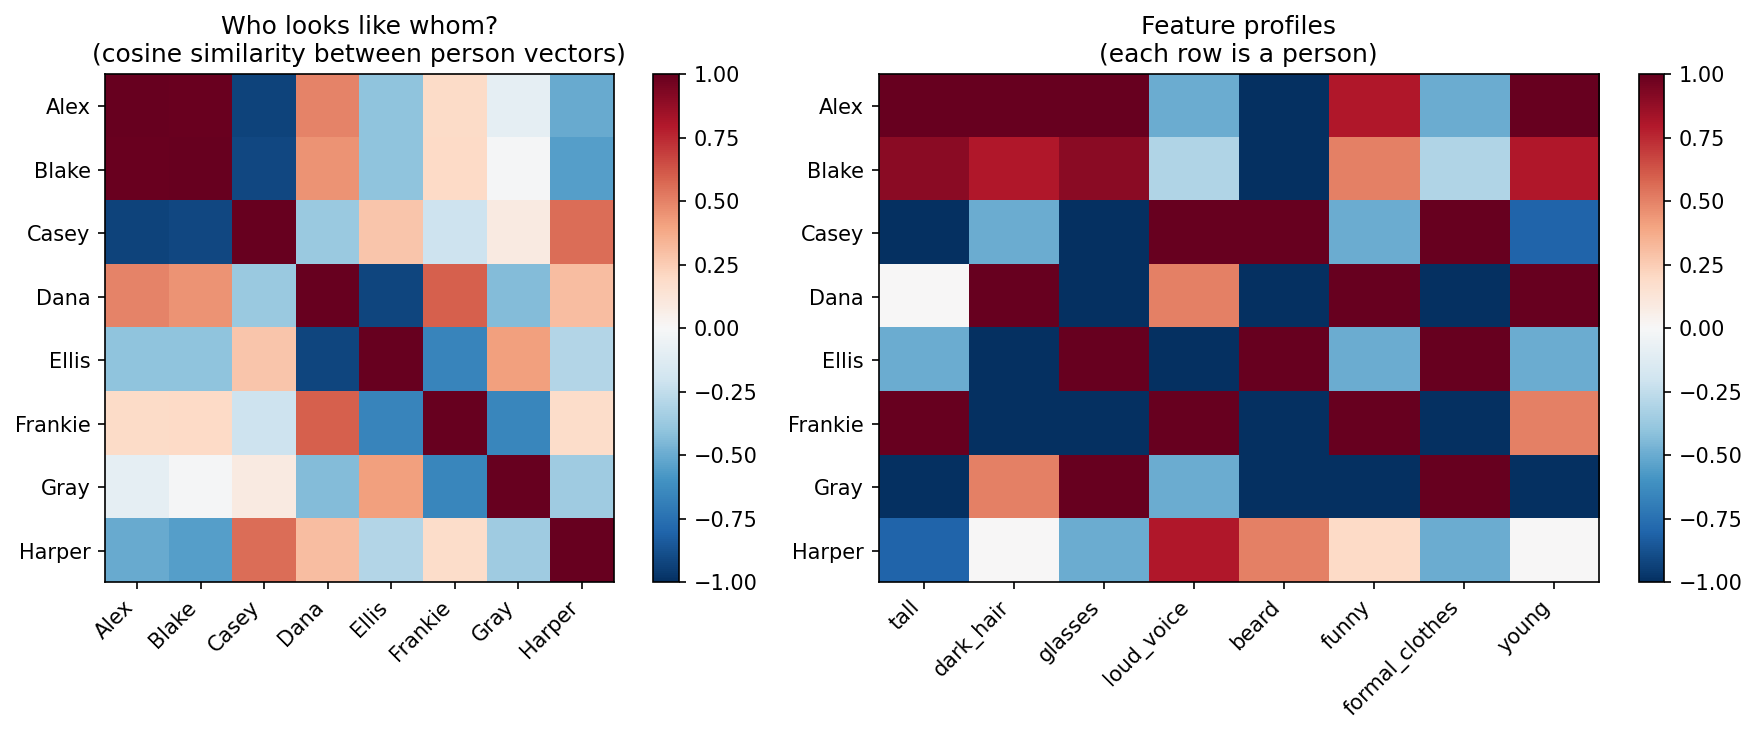


Notice: Alex and Blake are VERY similar (cosine sim = 0.989)
Casey and Frankie are quite different (cosine sim = -0.210)
This predicts where memory errors will occur...


In [17]:
# ============================================================
# VISUALIZE: WHO LOOKS LIKE WHOM?
# ============================================================
# Compute pairwise similarity between all people's feature vectors.
# This is the KEY similarity matrix — it determines what gets confused.

names = list(people.keys())
n = len(names)
person_vecs = np.array([people[name] for name in names])

# Cosine similarity between all pairs
from numpy.linalg import norm
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = np.dot(person_vecs[i], person_vecs[j]) / (
            norm(person_vecs[i]) * norm(person_vecs[j]) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: similarity matrix
im = axes[0].imshow(sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(names)
axes[0].set_title('Who looks like whom?\n(cosine similarity between person vectors)')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Right: feature profiles
axes[1].imshow(person_vecs, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(names)
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=45, ha='right')
axes[1].set_title('Feature profiles\n(each row is a person)')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"\nNotice: Alex and Blake are VERY similar (cosine sim = {sim_matrix[0,1]:.3f})")
print(f"Casey and Frankie are quite different (cosine sim = {sim_matrix[2,5]:.3f})")
print("This predicts where memory errors will occur...")


From Similarity to Retrieval: How "Attention" Works
When you query memory with a cue — "who was tall with dark hair and glasses?" — your memory system needs to turn raw similarities into a retrieval decision. This happens in two steps:
Step 1: Compute similarity. Take the dot product (or cosine similarity) between your query vector and every stored key vector. This gives you a raw score for each person in memory — higher means more similar to the query.
Step 2: Convert to attention weights via softmax. The raw similarities could be any numbers. We need to turn them into a probability distribution — a set of non-negative weights that sum to 1 — so we can take a weighted average of stored values. This is what softmax does:
attentioni=esimi/τ∑jesimj/τ\text{attention}_i = \frac{e^{\text{sim}_i / \tau}}{\sum_j e^{\text{sim}_j / \tau}}attentioni​=∑j​esimj​/τesimi​/τ​
The result is called retrieval attention — it tells you how much each stored memory contributes to what gets "retrieved." If one person's similarity is much higher than the rest, their attention weight will be close to 1 and everyone else's will be near 0 (sharp retrieval — you're confident it was Alex). If two people have similar scores, attention will be split between them (blurry retrieval — you're not sure if it was Alex or Blake).
The temperature τ\tau
τ controls how sharp or blurry the retrieval is. Low temperature → winner-take-all. High temperature → spread across many memories. This is the same softmax we saw in Week 1 for classification — but here it's doing memory retrieval rather than category selection.
This is the same mechanism the NTM's read head uses, and it's the same operation at the heart of Transformer attention. The math is identical — what changes is what's being attended over (memory slots, input tokens, or people at a party).

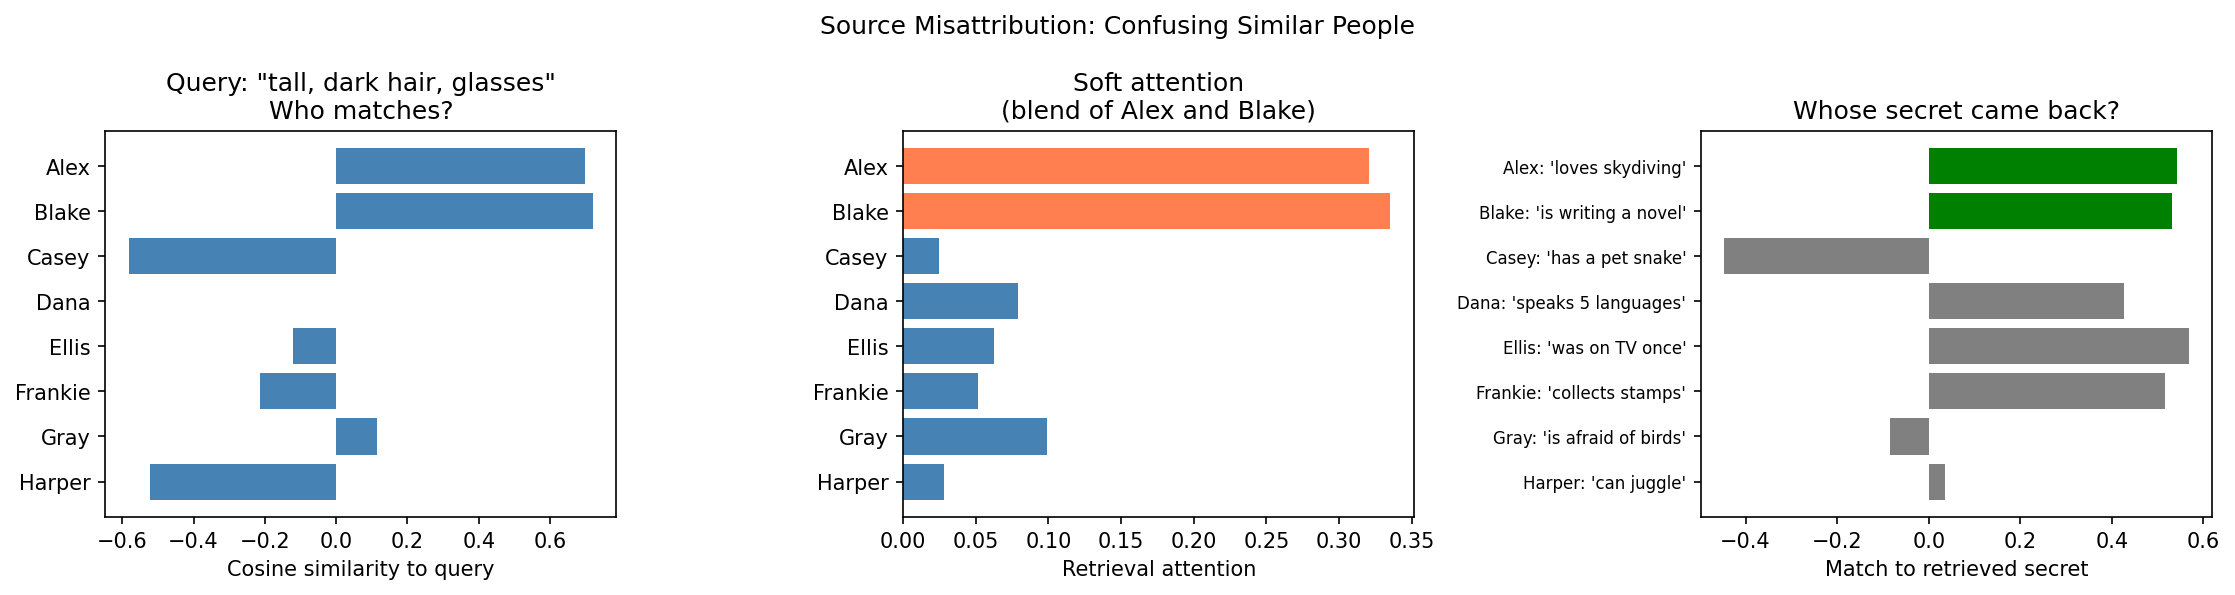

The query matches both Alex and Blake almost equally.
So you retrieve a BLEND of their secrets — you're not sure
whether it was Alex or Blake who told you about skydiving.
This is Schacter's 'misattribution' sin, arising directly from key similarity.


In [18]:
# ============================================================
# MEMORY RETRIEVAL: "What did that person tell me?"
# ============================================================
# Query: you're trying to remember what the tall person with dark hair
# and glasses told you. That describes BOTH Alex and Blake...

# Build the memory bank: keys = person vectors, values = secret vectors
keys = person_vecs.copy()
values = np.array([secrets[name] for name in names])

def retrieve_memory(query, keys, values, names, temperature=1.0):
    """Content-based retrieval with soft attention."""
    sims = np.array([np.dot(query, k) / (norm(query) * norm(k) + 1e-8) for k in keys])
    # Softmax attention
    exp_s = np.exp(sims / temperature)
    attn = exp_s / exp_s.sum()
    # Retrieved value is weighted sum
    retrieved = attn @ values
    return retrieved, attn, sims

# Query: "tall, dark hair, glasses" — this matches both Alex AND Blake
query = np.array([1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0])

retrieved_val, attention, similarities = retrieve_memory(query, keys, values, names, temperature=0.5)

# Which person's secret does the retrieved value most resemble?
secret_vecs = np.array([secrets[name] for name in names])
secret_matches = [np.corrcoef(retrieved_val, secrets[name])[0,1] for name in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: similarity of query to each person
axes[0].barh(range(n), similarities, color=['coral' if s > 0.8 else 'steelblue' for s in similarities])
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(names)
axes[0].set_xlabel('Cosine similarity to query')
axes[0].set_title('Query: "tall, dark hair, glasses"\nWho matches?')
axes[0].invert_yaxis()

# Middle: attention weights (who does the system actually retrieve?)
axes[1].barh(range(n), attention, color=['coral' if a > 0.15 else 'steelblue' for a in attention])
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(names)
axes[1].set_xlabel('Retrieval attention')
axes[1].set_title('Soft attention\n(blend of Alex and Blake)')
axes[1].invert_yaxis()

# Right: what secret did we retrieve vs. ground truth?
axes[2].barh(range(n), secret_matches, color=['green' if name in ['Alex','Blake'] else 'gray' for name in names])
axes[2].set_yticks(range(n)); axes[2].set_yticklabels([f"{name}: '{secret_labels[name]}'" for name in names], fontsize=8)
axes[2].set_xlabel('Match to retrieved secret')
axes[2].set_title('Whose secret came back?')
axes[2].invert_yaxis()

plt.suptitle('Source Misattribution: Confusing Similar People', fontsize=12)
plt.tight_layout()
plt.show()

print("The query matches both Alex and Blake almost equally.")
print("So you retrieve a BLEND of their secrets — you're not sure")
print("whether it was Alex or Blake who told you about skydiving.")
print("This is Schacter's 'misattribution' sin, arising directly from key similarity.")


=== Adding a distinctive feature to Alex ===



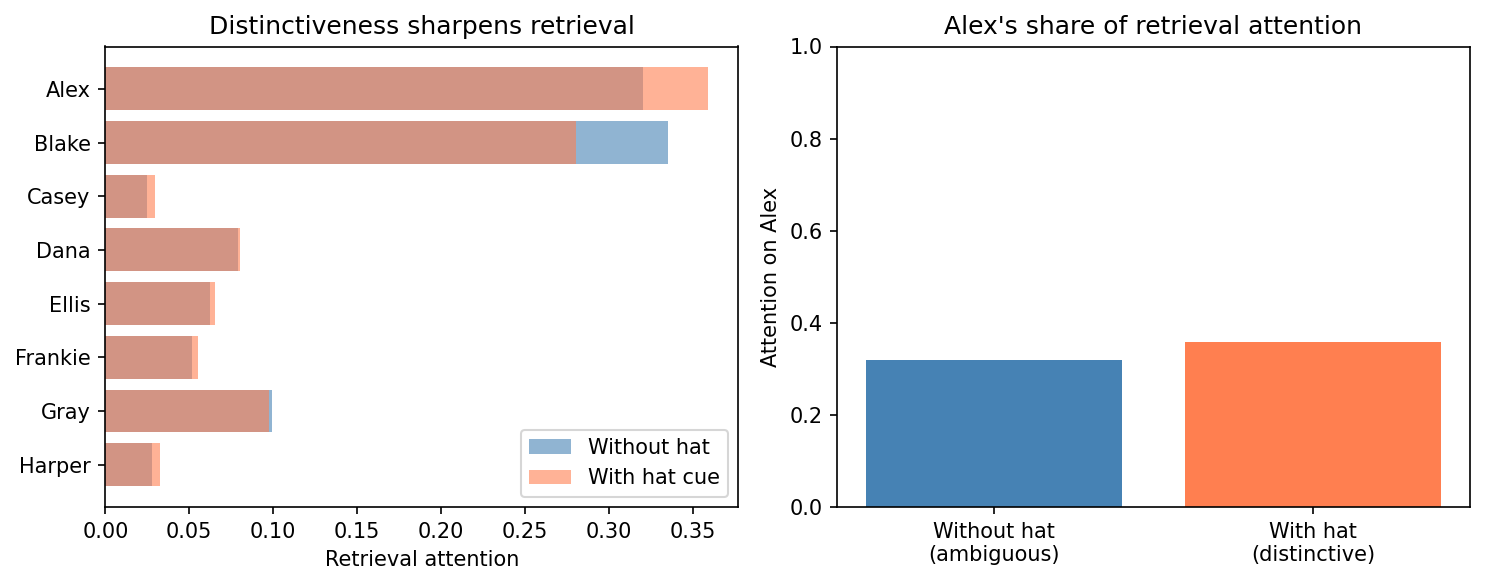

The 'ridiculous hat' is a distinctive encoding cue.
It makes Alex's key vector unique, so the query matches Alex sharply.
This is the 'distinctiveness effect' in memory research:
bizarre or unique features improve recall because they reduce key overlap.

It's also why mnemonics work — they add distinctive features to otherwise
similar-looking keys, making each one easier to retrieve individually.


In [19]:
# ============================================================
# THE DISTINCTIVENESS EFFECT
# ============================================================
# What if one person was wearing a ridiculous hat?
# Adding a distinctive feature makes their key vector unique,
# which makes retrieval much sharper.

print("=== Adding a distinctive feature to Alex ===\n")

# Give Alex a unique 9th feature: "wearing_ridiculous_hat"
feature_names_ext = feature_names + ['ridiculous_hat']
people_ext = {}
for name, vec in people.items():
    # Everyone gets 0 on the hat feature except Alex
    people_ext[name] = np.append(vec, 1.0 if name == 'Alex' else 0.0)

keys_ext = np.array([people_ext[name] for name in names])

# Now query specifically for the hat-wearer
query_hat = np.array([1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0])  # tall, dark, glasses, HAT

retrieved_hat, attn_hat, sims_hat = retrieve_memory(query_hat, keys_ext, values, names, temperature=0.5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Compare attention before and after
axes[0].barh(range(n), attention, color='steelblue', alpha=0.6, label='Without hat')
axes[0].barh(range(n), attn_hat, color='coral', alpha=0.6, label='With hat cue')
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(names)
axes[0].set_xlabel('Retrieval attention')
axes[0].set_title('Distinctiveness sharpens retrieval')
axes[0].legend()
axes[0].invert_yaxis()

# The hat makes Alex pop out
axes[1].bar(['Without hat\n(ambiguous)', 'With hat\n(distinctive)'],
            [attention[0], attn_hat[0]], color=['steelblue', 'coral'])
axes[1].set_ylabel('Attention on Alex')
axes[1].set_title("Alex's share of retrieval attention")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("The 'ridiculous hat' is a distinctive encoding cue.")
print("It makes Alex's key vector unique, so the query matches Alex sharply.")
print("This is the 'distinctiveness effect' in memory research:")
print("bizarre or unique features improve recall because they reduce key overlap.")
print()
print("It's also why mnemonics work — they add distinctive features to otherwise")
print("similar-looking keys, making each one easier to retrieve individually.")


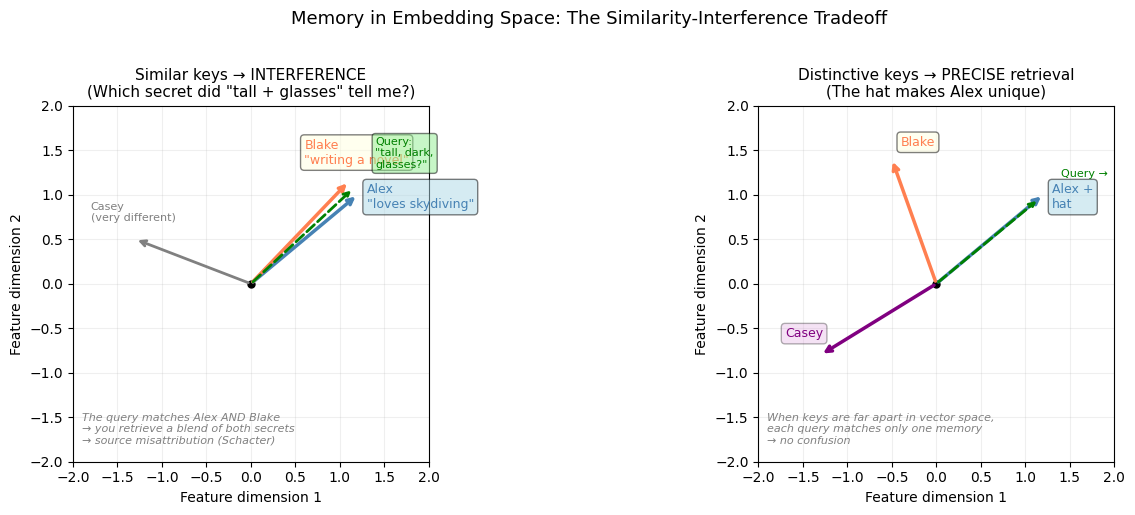

In [13]:
# ============================================================
# VISUALIZING: WHY SIMILAR KEYS CAUSE MEMORY INTERFERENCE
# ============================================================
# This diagram shows the core tradeoff:
#   Similar keys → easy generalization BUT retrieval confusion
#   Distinctive keys → precise retrieval BUT no generalization

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT: Similar keys cause interference ---
ax = axes[0]
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')

# Draw two very similar key vectors (Alex and Blake at the party)
ax.annotate('', xy=(1.2, 1.0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.annotate('', xy=(1.1, 1.15), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='coral', lw=2.5))
# A query that matches both
ax.annotate('', xy=(1.15, 1.07), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2, linestyle='dashed'))

ax.text(1.3, 0.85, 'Alex\n"loves skydiving"', fontsize=9, color='steelblue',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.text(0.6, 1.35, 'Blake\n"writing a novel"', fontsize=9, color='coral',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
ax.text(1.4, 1.3, 'Query:\n"tall, dark,\nglasses?"', fontsize=8, color='green',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# A very different person
ax.annotate('', xy=(-1.3, 0.5), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.text(-1.8, 0.7, 'Casey\n(very different)', fontsize=8, color='gray')

ax.plot(0, 0, 'ko', markersize=5)
ax.set_title('Similar keys → INTERFERENCE\n(Which secret did "tall + glasses" tell me?)', fontsize=11)
ax.text(-1.9, -1.8, 'The query matches Alex AND Blake\n→ you retrieve a blend of both secrets\n→ source misattribution (Schacter)',
        fontsize=8, style='italic', color='gray')
ax.set_xlabel('Feature dimension 1')
ax.set_ylabel('Feature dimension 2')
ax.grid(alpha=0.2)

# --- RIGHT: Distinctive keys enable precise retrieval ---
ax = axes[1]
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')

ax.annotate('', xy=(1.2, 1.0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.annotate('', xy=(-0.5, 1.4), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='coral', lw=2.5))
ax.annotate('', xy=(-1.3, -0.8), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))
# Query matches only one
ax.annotate('', xy=(1.15, 0.95), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2, linestyle='dashed'))

ax.text(1.3, 0.85, 'Alex +\nhat', fontsize=9, color='steelblue',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.text(-0.4, 1.55, 'Blake', fontsize=9, color='coral',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
ax.text(-1.7, -0.6, 'Casey', fontsize=9, color='purple',
        bbox=dict(boxstyle='round', facecolor='plum', alpha=0.3))
ax.text(1.4, 1.2, 'Query →', fontsize=8, color='green')

ax.plot(0, 0, 'ko', markersize=5)
ax.set_title('Distinctive keys → PRECISE retrieval\n(The hat makes Alex unique)', fontsize=11)
ax.text(-1.9, -1.8, 'When keys are far apart in vector space,\neach query matches only one memory\n→ no confusion',
        fontsize=8, style='italic', color='gray')
ax.set_xlabel('Feature dimension 1')
ax.set_ylabel('Feature dimension 2')
ax.grid(alpha=0.2)

plt.suptitle('Memory in Embedding Space: The Similarity-Interference Tradeoff', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


> **Discussion Question:** The party demo shows that memory errors arise from *similarity between keys*. This is the same math that makes memory *useful* — similar queries retrieve similar results, which is how you generalize ("this new dog looks like other dogs I've seen → it's probably a dog"). The same property that enables generalization *causes* interference. Is there a way to have one without the other?
>
> Think about the **testing effect** in education: you remember material better if you're *tested* on it rather than just re-reading it. How might testing change the key vectors in a way that reduces interference?


### From People to Words: Vector Spaces in Language

The party demo used hand-crafted feature vectors for people. But what if we could *learn* feature vectors automatically from data? This is exactly what **word2vec** (Mikolov et al., 2013) does for words.

**The core idea:** train a simple neural network to predict a word from its surrounding context (or vice versa). The hidden layer activations become the word's **embedding** — a vector that captures its meaning. Words that appear in similar contexts get similar vectors:

- "king" and "queen" are nearby (both appear in contexts about royalty)
- "cat" and "dog" are nearby (both appear in contexts about pets)
- "cat" and "democracy" are far apart (rarely share context)

This is the same principle as our party memory: **entities that share features (or contexts) have similar vectors**. And the same consequences follow — similar vectors enable generalization but cause interference.

The most famous demonstration of word2vec's power is **vector arithmetic on concepts:**

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

This works because the vector difference $\vec{\text{king}} - \vec{\text{man}}$ captures something like "royalty" — and adding that to $\vec{\text{woman}}$ lands you near "queen." The similarity structure isn't hand-designed; it *emerged* from training on text.


Vector arithmetic on concepts:
  king - man + woman = [ 1.  -1.   0.5  1.   1. ]
  Closest word: 'queen' (similarity: 1.000)



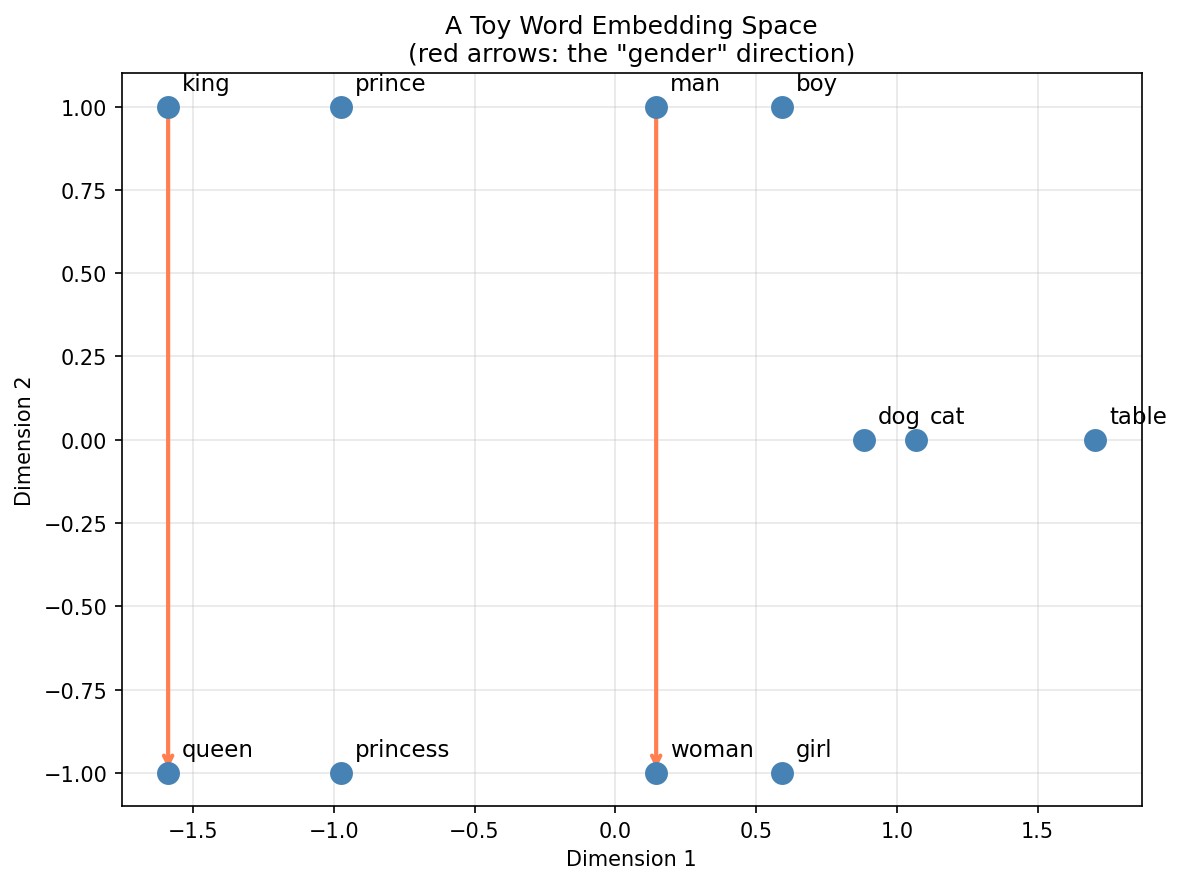

Notice: king→queen and man→woman are PARALLEL arrows.
The 'gender' direction is a consistent axis in the space.
This is why king - man + woman ≈ queen works — it's vector translation.


In [20]:
# ============================================================
# A TOY WORD2VEC-STYLE EMBEDDING SPACE
# ============================================================
# We'll create a small hand-crafted embedding space to illustrate
# the same principles. In practice, these vectors are LEARNED from
# billions of words of text — but the math is identical.

# Each word is a 5-dimensional vector capturing semantic features:
# [royalty, gender(M+/F-), age(old+/young-), power, animacy]

word_vectors = {
    'king':    np.array([ 1.0,  1.0,  0.5,  1.0,  1.0]),
    'queen':   np.array([ 1.0, -1.0,  0.5,  1.0,  1.0]),
    'man':     np.array([-0.5,  1.0,  0.3,  0.0,  1.0]),
    'woman':   np.array([-0.5, -1.0,  0.3,  0.0,  1.0]),
    'prince':  np.array([ 0.8,  1.0, -1.0,  0.5,  1.0]),
    'princess':np.array([ 0.8, -1.0, -1.0,  0.5,  1.0]),
    'boy':     np.array([-0.5,  1.0, -1.0, -0.5,  1.0]),
    'girl':    np.array([-0.5, -1.0, -1.0, -0.5,  1.0]),
    'dog':     np.array([-1.0,  0.0, -0.3, -0.5,  1.0]),
    'cat':     np.array([-1.0,  0.0, -0.3, -0.8,  1.0]),
    'table':   np.array([-1.0,  0.0,  0.0, -1.0, -1.0]),
}

# The famous analogy: king - man + woman = ?
result = word_vectors['king'] - word_vectors['man'] + word_vectors['woman']

# Find the closest word to the result
best_word = None
best_sim = -999
for word, vec in word_vectors.items():
    if word in ['king', 'man', 'woman']:
        continue  # skip the query words
    sim = np.dot(result, vec) / (norm(result) * norm(vec))
    if sim > best_sim:
        best_sim = sim
        best_word = word

print("Vector arithmetic on concepts:")
print(f"  king - man + woman = {result}")
print(f"  Closest word: '{best_word}' (similarity: {best_sim:.3f})")
print()

# Visualize the embedding space (project to 2D for display)
from numpy.linalg import svd
words = list(word_vectors.keys())
vecs = np.array([word_vectors[w] for w in words])
U, S, Vt = svd(vecs - vecs.mean(axis=0), full_matrices=False)
proj = U[:, :2] * S[:2]

plt.figure(figsize=(8, 6))
plt.scatter(proj[:, 0], proj[:, 1], s=100, c='steelblue', zorder=5)
for i, word in enumerate(words):
    plt.annotate(word, (proj[i, 0] + 0.05, proj[i, 1] + 0.05), fontsize=11)

# Draw the analogy arrow
king_idx = words.index('king')
queen_idx = words.index('queen')
man_idx = words.index('man')
woman_idx = words.index('woman')
plt.annotate('', xy=proj[queen_idx], xytext=proj[king_idx],
             arrowprops=dict(arrowstyle='->', color='coral', lw=2))
plt.annotate('', xy=proj[woman_idx], xytext=proj[man_idx],
             arrowprops=dict(arrowstyle='->', color='coral', lw=2))

plt.title('A Toy Word Embedding Space\n(red arrows: the "gender" direction)')
plt.xlabel('Dimension 1'); plt.ylabel('Dimension 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: king→queen and man→woman are PARALLEL arrows.")
print("The 'gender' direction is a consistent axis in the space.")
print("This is why king - man + woman ≈ queen works — it's vector translation.")


### The Deep Connection: Embedding Spaces *Are* Memory Spaces

Now connect the dots:

**At the party**, each person was a vector. Retrieval meant finding the stored vector most similar to your query. Errors happened when two people had similar vectors (Alex and Blake). Adding a distinctive feature (the hat) pushed vectors apart and improved retrieval.

**In word2vec**, each word is a vector. Retrieval (e.g., "what word means X?") means finding the vector most similar to a query. The system naturally confuses "dog" and "cat" because they have similar vectors — just as you might say "cat" when you meant "dog."

**In systems w/ External Memories**, keys and values are vectors. The read head computes cosine similarity between a query and stored keys, then returns a weighted sum of values. The math is *identical* to what we just did at the party.

**In the brain**, neural population codes are vectors — patterns of firing rates across a population of neurons. Retrieval via pattern completion works by the same similarity logic. And the same failure modes apply: similar patterns interfere.

The unifying principle: **any system that represents information as vectors and retrieves by similarity will exhibit the same tradeoff between generalization and interference.** This is not a bug in any one architecture — it's a mathematical property of similarity-based retrieval in vector spaces. It's why some of Schacter's 7 sins aren't design flaws; they're the *necessary cost* of a system that can generalize.

> ** Discussion Question:** Word2vec embeddings notoriously encode social biases — for example, $\vec{\text{doctor}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{nurse}}$. This is a form of Schacter's "bias" sin: the statistical regularities in the training data (text from the internet) get encoded in the vector space. If you used these embeddings as keys in a memory system, what would happen when you tried to retrieve "doctor"? How does this connect to the rational analysis of memory from Week 3 — where we saw that networks' "spontaneous thoughts" reflect the frequency distribution of their training data?


---
## How <b> External Memory </b> Actually Works: Read Heads and Write Heads

We've seen that key-value memory lets us store and retrieve associations. Now let's look at how a **Neural Turing Machine** (Graves et al., 2014) implements this using differentiable vector operations — operations that gradients can flow through, so the network can *learn* how to use its memory.



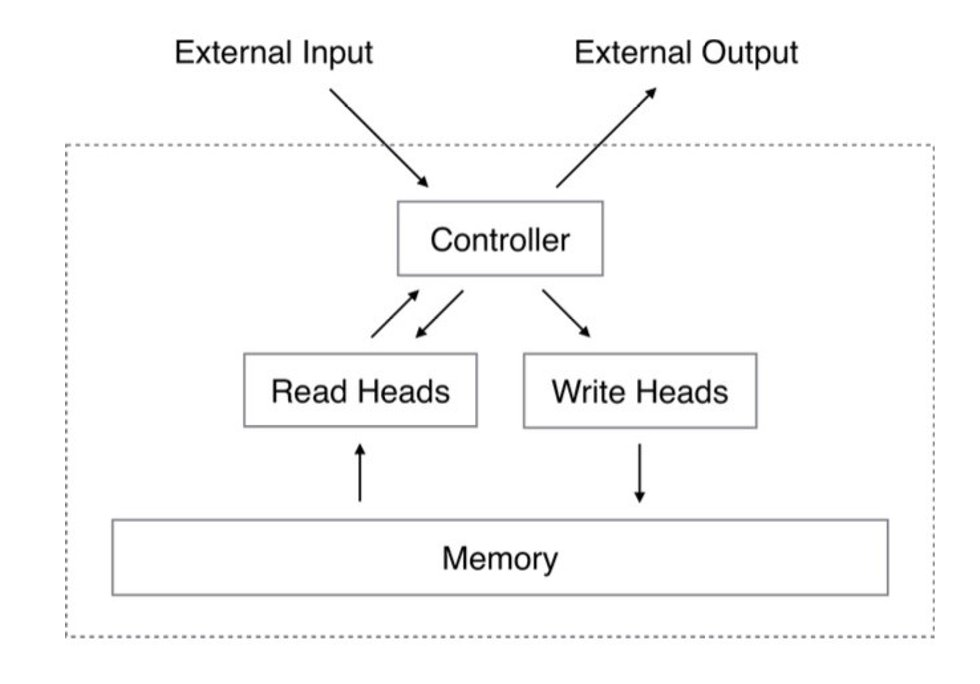

*The Neural Turing Machine (Graves et al., 2014): a Controller (neural network) interacts with an external Memory through separate Read and Write Heads. The controller receives external input, uses the read head to retrieve information from memory, uses the write head to store new information, and produces external output. The heads are "soft" — they attend over all memory locations via learned attention weights.*


### What Is a "Head"?

The term **"head"** comes from Alan Turing's original 1936 thought experiment: a Turing machine is an infinite tape (memory) plus a **head** that can move along the tape, reading symbols from it and writing symbols to it. The head is the *mechanism of access* — it's what stands between the processor and the stored information.

In an NTM, "head" means the same thing conceptually, but it's implemented as a **small neural network that produces vectors**. Concretely:

- A **read head** is a small set of learned weights that takes the controller's current state and outputs a **query vector** — "what am I looking for?" That query is compared against everything in memory (via cosine similarity), producing an attention distribution. The attention-weighted average of memory contents is what gets "read out."

- A **write head** is another small set of learned weights that takes the controller's current state and outputs two things: (a) a **key vector** — "where should I write?" (used to determine which memory slot to target), and (b) a **content vector** — "what should I write there?"

So a head is a **learned function** that translates the controller's internal state into vectors that interact with the memory bank. The network learns *how to use its own memory* through gradient descent, just as it learns everything else.

Here's the analogy to keep in mind:

| Turing Machine | NTM | Brain (hypothesis) |
|---|---|---|
| Tape (permanent storage) | Memory bank (matrix $M$) | **Cortex** — where consolidated long-term memories are stored in synaptic weights |
| Read head | Learned read-query function | **Hippocampal retrieval circuitry** — pattern completion that reactivates cortical traces |
| Write head | Learned write-key/value function | **Hippocampal encoding circuitry** — rapid binding via LTP in dentate gyrus / CA3 |
| Temporary buffer | Recently-written memory slots | **Cortex? PFC?** — fast temporary storage before consolidation |
| Processor | Controller (LSTM/MLP) | **Prefrontal cortex** — executive control, decides what to attend to, encode, and retrieve |

**An important subtlety:** the hippocampus plays a dual role — it is both the **read/write head** (the mechanism that encodes and retrieves) *and* a **temporary buffer** (a fast-learning store for recent memories). But it is *not* the permanent tape. The permanent tape is the cortex, where memories are slowly consolidated over days to years.

This is why H.M.'s surgery produced the pattern it did. Removing the hippocampus destroyed the head mechanism, but left the cortical "tape" intact:
- Old memories (already consolidated to the cortical tape) → **preserved**
- Recent memories (still in the buffer, not yet consolidated) → **lost** (H.M. did show some retrograde amnesia for events close to the surgery)
- New memories (require the write head to encode) → **impossible**

If the hippocampus *were* the tape, H.M. should have lost everything. The fact that he didn't is strong evidence that permanent storage lives elsewhere — and that the hippocampus is the *access mechanism*, not the warehouse.

# NTM Architecture

An NTM has four components:

**1. The Memory Bank (M)** — A matrix of shape $(N \times D)$: $N$ memory slots, each a $D$-dimensional vector. Think of this as a notebook with $N$ pages, each page holding a $D$-dimensional pattern.

**2. The Write Head** — A small neural network that produces:
- A **write key** $\mathbf{k}_w$: compared against existing slots to determine *where* to write
- A **write attention** $\mathbf{w}_w$: a probability distribution over slots (computed via softmax over similarities)
- An **erase vector** $\mathbf{e}$: what to remove from the selected slot
- An **add vector** $\mathbf{a}$: what to store in the selected slot

The write operation: $M_i \leftarrow M_i \cdot (1 - w_i \cdot \mathbf{e}) + w_i \cdot \mathbf{a}$

**3. The Read Head** — A small neural network that produces:
- A **read key** $\mathbf{k}_r$: compared against stored content to determine *where* to read
- A **read attention** $\mathbf{w}_r$: a probability distribution over slots
- A **read vector** $\mathbf{r}$: the weighted sum of memory contents: $\mathbf{r} = \sum_i w_i \cdot M_i$

Notably, **reading is a weighted average, not a hard lookup**. If the read attention is sharply peaked on one slot, you get approximately that slot's contents. If it's spread across several, you get a blend. This is "soft" attention — differentiable, so gradients can flow through it during training.

**4. The Controller** — A neural network (often an LSTM) that decides what to read, what to write, and what to output. It receives the current input *plus* whatever was read from memory on the previous step. The controller is the "brain" of the system; the memory is its external resource.

> **Discussion Question:** Returning to Marr's levels — the NTM is an *implementation* of the key-value memory *algorithm* we've been exploring. The brain presumably implements the same algorithm using neurons. What specific predictions does the NTM architecture make about the brain? For example: does the brain need separate "read" and "write" circuitry?

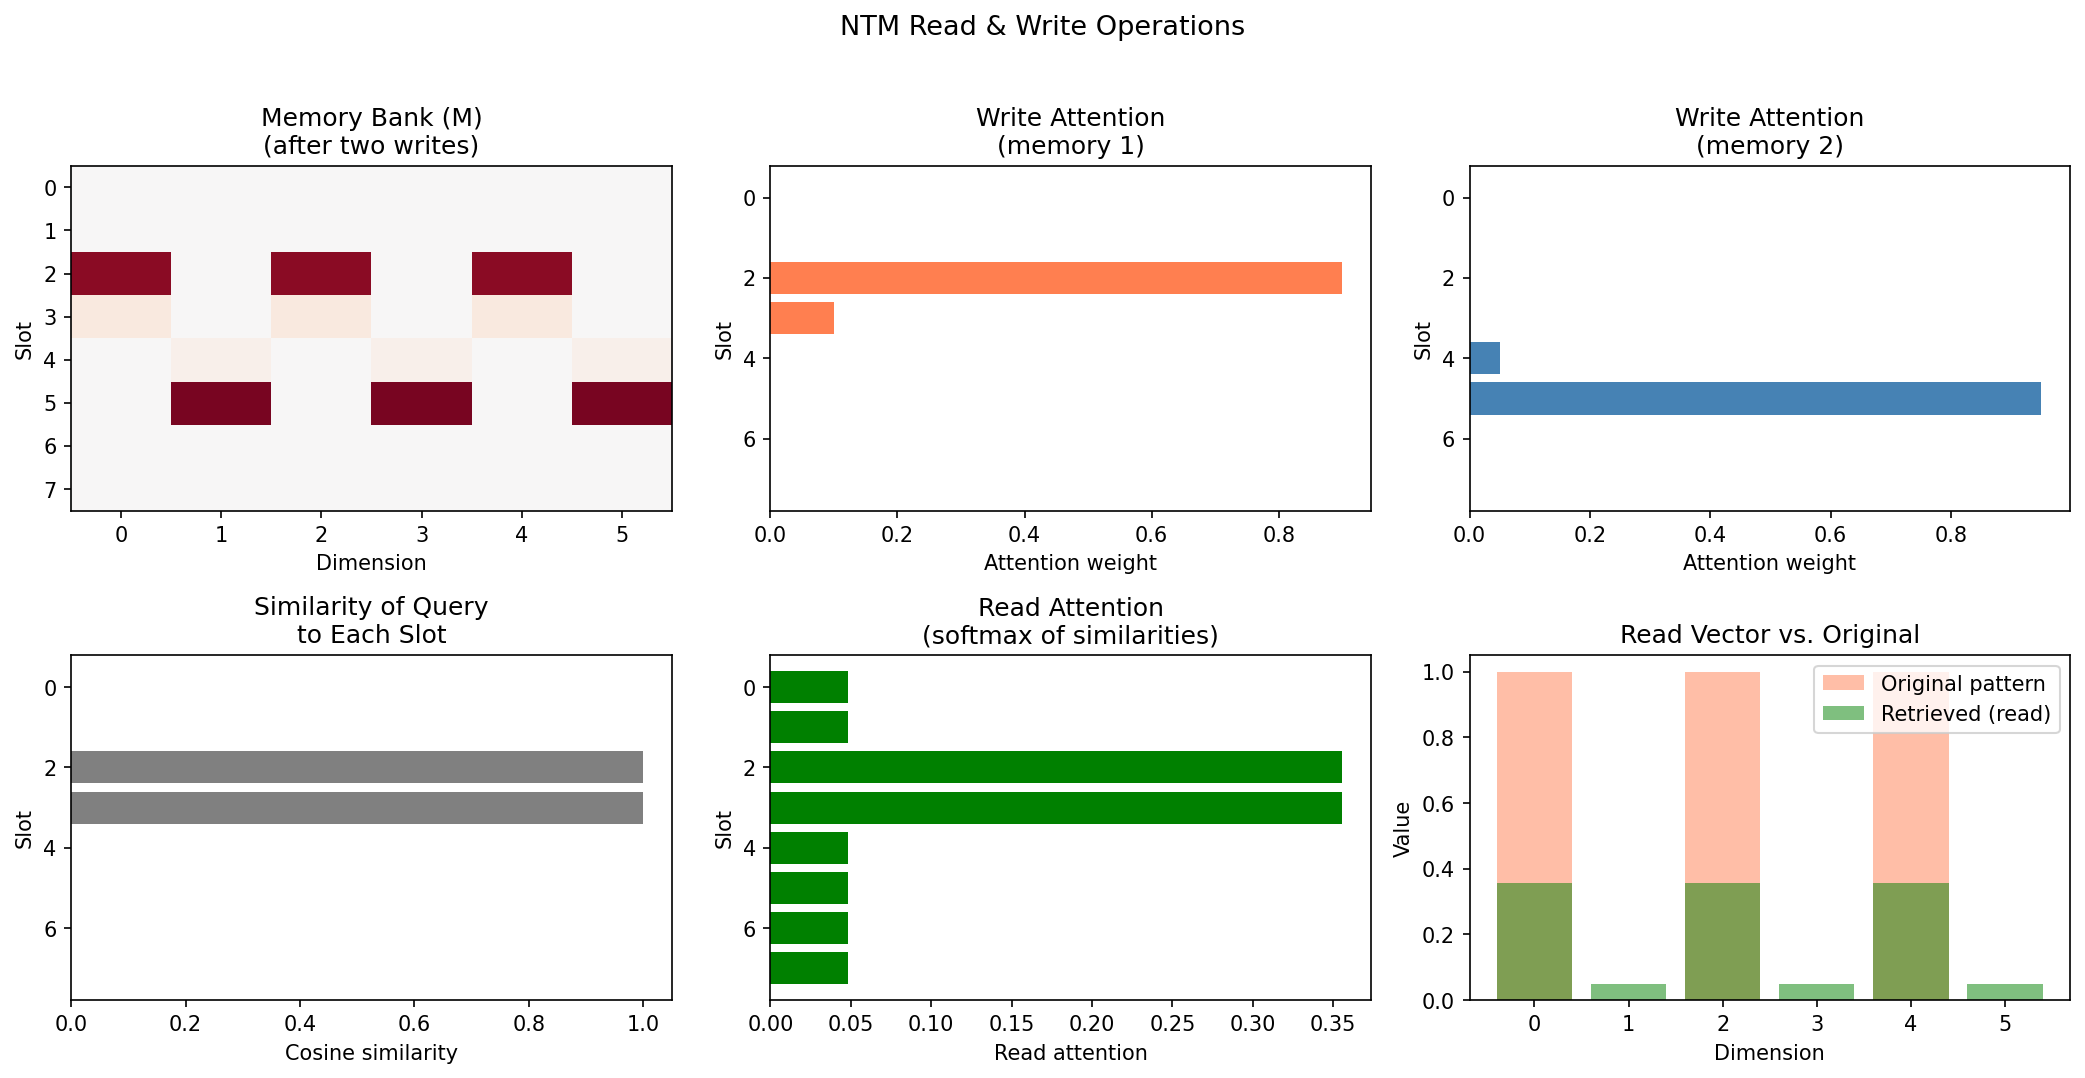

Key insight: the read head doesn't do a hard lookup.
It computes a SOFT attention over all slots and returns a weighted average.
This is differentiable — gradients can flow through it during training.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

# ============================================================
# VISUALIZING HOW READ AND WRITE HEADS WORK
# ============================================================

# Start with a small memory bank: 8 slots, each 6-dimensional
n_slots = 8
mem_dim = 6

# Initialize memory to zeros (blank notebook)
M = np.zeros((n_slots, mem_dim))

# --- WRITE OPERATION ---
# Suppose we want to store the pattern [1, 0, 1, 0, 1, 0] in slot 2.
# In a hard-write, we'd just set M[2] = pattern.
# In a SOFT write, we produce an attention distribution over all slots.

write_attention = np.zeros(n_slots)
write_attention[2] = 0.9   # mostly write to slot 2
write_attention[3] = 0.1   # a little bleed into slot 3

add_vector = np.array([1, 0, 1, 0, 1, 0], dtype=float)

# Write: each slot gets (attention weight × add vector) added
for i in range(n_slots):
    M[i] += write_attention[i] * add_vector

# Write a second memory to slot 5
write_attention2 = np.zeros(n_slots)
write_attention2[5] = 0.95
write_attention2[4] = 0.05
add_vector2 = np.array([0, 1, 0, 1, 0, 1], dtype=float)
for i in range(n_slots):
    M[i] += write_attention2[i] * add_vector2

# --- READ OPERATION ---
# Now suppose we want to read using a query that's similar to add_vector.
# We compute cosine similarity between the query and each slot.
query = np.array([1, 0, 1, 0, 1, 0], dtype=float)

# Cosine similarity
sims = np.array([np.dot(query, M[i]) / (np.linalg.norm(query) * np.linalg.norm(M[i]) + 1e-8)
                 for i in range(n_slots)])

# Softmax to get read attention (with temperature for sharpness)
temperature = 0.5
exp_sims = np.exp(sims / temperature)
read_attention = exp_sims / exp_sims.sum()

# Read: weighted sum of memory contents
read_vector = np.sum(read_attention[:, None] * M, axis=0)

# --- VISUALIZE ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Memory contents
axes[0, 0].imshow(M, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0, 0].set_xlabel('Dimension'); axes[0, 0].set_ylabel('Slot')
axes[0, 0].set_title('Memory Bank (M)\n(after two writes)')

# Write attention for memory 1
axes[0, 1].barh(range(n_slots), write_attention, color='coral')
axes[0, 1].set_xlabel('Attention weight'); axes[0, 1].set_ylabel('Slot')
axes[0, 1].set_title('Write Attention\n(memory 1)')
axes[0, 1].invert_yaxis()

# Write attention for memory 2
axes[0, 2].barh(range(n_slots), write_attention2, color='steelblue')
axes[0, 2].set_xlabel('Attention weight'); axes[0, 2].set_ylabel('Slot')
axes[0, 2].set_title('Write Attention\n(memory 2)')
axes[0, 2].invert_yaxis()

# Read query similarity
axes[1, 0].barh(range(n_slots), sims, color='gray')
axes[1, 0].set_xlabel('Cosine similarity'); axes[1, 0].set_ylabel('Slot')
axes[1, 0].set_title('Similarity of Query\nto Each Slot')
axes[1, 0].invert_yaxis()

# Read attention (after softmax)
axes[1, 1].barh(range(n_slots), read_attention, color='green')
axes[1, 1].set_xlabel('Read attention'); axes[1, 1].set_ylabel('Slot')
axes[1, 1].set_title('Read Attention\n(softmax of similarities)')
axes[1, 1].invert_yaxis()

# Retrieved vector vs original
axes[1, 2].bar(range(mem_dim), add_vector, alpha=0.5, label='Original pattern', color='coral')
axes[1, 2].bar(range(mem_dim), read_vector, alpha=0.5, label='Retrieved (read)', color='green')
axes[1, 2].set_xlabel('Dimension'); axes[1, 2].set_ylabel('Value')
axes[1, 2].set_title('Read Vector vs. Original')
axes[1, 2].legend()

plt.suptitle('NTM Read & Write Operations', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: the read head doesn't do a hard lookup.")
print("It computes a SOFT attention over all slots and returns a weighted average.")
print("This is differentiable — gradients can flow through it during training.")


### Why Soft Attention Matters

In the country-capital exercise earlier, we used `argmax` — a hard lookup that picks the single most similar key. This works for retrieval, but it has a fatal flaw: **argmax is not differentiable**. You can't compute a gradient through "pick the biggest one," so you can't train the system end-to-end with backpropagation.

The NTM's solution: replace `argmax` with **softmax**. Instead of picking one slot, produce a *probability distribution* over all slots. If the distribution is sharply peaked, the behavior is almost the same as argmax — but now gradients can flow through it. The controller can learn *what to attend to* because the attention weights are differentiable functions of the query.

This is the same trick that Transformers use. In fact, the NTM's content-based addressing is essentially the same operation as Transformer self-attention — both compute softmax(QK^T)V. The NTM just uses it for external memory rather than for attending over input tokens. We will cover this next week!


### A Modern Application: Retrieval-Augmented Generation (RAG)

The NTM architecture might seem like a research curiosity, but the same principle is currently one of the most important techniques in commercial AI. It's called **Retrieval-Augmented Generation (RAG)**, and it's how modern LLMs like ChatGPT, Claude, and others handle information they weren't trained on.

**The problem RAG solves:** A large language model's knowledge is frozen in its weights at training time. It can't know about events after its training cutoff, it can't access your company's private documents, and it sometimes "hallucinates" — confidently generating information that sounds right but isn't. These are all failures of weight-based memory, exactly analogous to the limitations we've been studying.

**The RAG architecture maps directly onto the NTM:**

| NTM Component | RAG Equivalent |
|---|---|
| **Controller** | The LLM (GPT, Claude, etc.) — processes the user's query and generates responses |
| **Memory bank** | A database of documents, chunked into passages and stored as embedding vectors |
| **Read head** | A retrieval system that takes the user's query, converts it to an embedding (the read key), computes similarity against all stored passages, and returns the best matches |
| **Write head** | The indexing pipeline that converts documents into embeddings and stores them in the database |

**How it works in practice:**
1. A user asks: "What was our Q3 revenue?"
2. The **read head** converts the question to a vector and searches the document database for relevant passages (soft attention over stored keys!)
3. The retrieved passages are injected into the LLM's context window
4. The **controller** (LLM) generates a response grounded in the retrieved documents

**Why this matters for cognitive science:** RAG was invented because **you can't store everything in the weights**. Weight-based memory is slow to update, prone to interference, and can't handle rapidly changing information. External memory — whether it's the hippocampus/cortex, an NTM memory bank, or a vector database — is the solution.

The parallel goes deeper: just as the brain's cortex slowly consolidates important hippocampal memories into long-term weight-based storage, LLM developers periodically *retrain* their models on important new information, moving it from the external database into the weights. The external memory is fast but ephemeral; the weights are slow but durable. Complementary learning systems, all over again.

> ** Discussion Question:** When an LLM using RAG retrieves a document and uses it to answer a question, is it "remembering" in any meaningful sense? How is this similar to and different from a human remembering a fact they read in a textbook? What about Schacter's sins — could a RAG system exhibit misattribution (retrieving the wrong document but presenting it confidently)? Could it exhibit suggestibility (if someone plants misleading documents in the database)?


---
## Lesioning the Memory System: Simulating Brain Damage

### Patient H.M. and the Dissociation of Memory Systems

In 1953, Henry Molaison (known as Patient H.M.) underwent bilateral removal of his medial temporal lobes — including most of his hippocampus — to treat severe epilepsy. The surgery cured his seizures but produced one of the most studied neuropsychological cases in history.

**What H.M. could still do after surgery:**
- Remember events from *before* the surgery (intact remote **retrograde** memory)
- Hold information in mind for short periods (intact **working memory**)
- Learn new motor skills like mirror tracing (intact **procedural** memory)
- Speak fluently and understand language

**What H.M. could not do:**
- Form *new* long-term declarative memories (**anterograde amnesia**). He could meet you, have a conversation, and five minutes later have no memory of ever seeing you.

### The NTM Interpretation

If we think of the hippocampus as implementing something like a **write head** to an external memory bank, then H.M.'s surgery is equivalent to **destroying the write head while leaving the read head and stored memories intact**:

- ✅ Read head intact → can retrieve old memories
- ❌ Write head destroyed → cannot form new memories
- ✅ Controller (cortex) intact → can think, speak, reason

Let's build an NTM-style memory system and test this.


In [23]:
# ============================================================
# NTM-STYLE EXTERNAL MEMORY WITH LESIONABLE READ/WRITE HEADS
# ============================================================
# This implements the key NTM operations using numpy

class NTMStyleMemory:
    def __init__(self, n_slots=20, mem_dim=16, temperature=1.0):
        """
        n_slots:     number of memory slots (pages in the notebook)
        mem_dim:     dimensionality of each slot
        temperature: controls sharpness of attention (lower = sharper)
        """
        self.n_slots = n_slots
        self.mem_dim = mem_dim
        self.temperature = temperature

        # The memory bank: a matrix M of shape (n_slots × mem_dim)
        self.M = np.zeros((n_slots, mem_dim))

        # Track which slots have been written to
        self.write_ptr = 0

        # Lesion flags
        self.write_enabled = True
        self.read_enabled = True

    def _content_attention(self, query):
        """
        Compute soft attention over memory slots using content-based addressing.
        This is the core NTM operation: softmax(similarity(query, M) / temperature)

        Returns a probability distribution over slots — the "attention weights."
        """
        # Cosine similarity between query and each stored memory
        norms = np.linalg.norm(self.M[:self.write_ptr], axis=1, keepdims=True) + 1e-8
        query_norm = np.linalg.norm(query) + 1e-8
        similarities = (self.M[:self.write_ptr] @ query) / (norms.squeeze() * query_norm)

        # Softmax with temperature
        exp_sim = np.exp(similarities / self.temperature)
        attention = exp_sim / (exp_sim.sum() + 1e-8)
        return attention

    def write(self, key, value):
        """
        WRITE HEAD: store a key-value pair.
        In a full NTM, the write head uses attention to decide WHERE to write.
        Here we write to the next available slot (sequential allocation).
        The key is stored as the slot content, and value is concatenated.
        """
        if not self.write_enabled:
            return False
        if self.write_ptr >= self.n_slots:
            return False

        # Store: first half = key, second half = value
        # (In a real NTM, key and value are entangled in the slot content)
        self.M[self.write_ptr, :self.mem_dim//2] = key
        self.M[self.write_ptr, self.mem_dim//2:] = value
        self.write_ptr += 1
        return True

    def read(self, query):
        """
        READ HEAD: given a query, compute attention over stored keys,
        then return a weighted sum of the corresponding values.

        This is the NTM's content-based read:
          1. Compute similarity(query, each stored key)
          2. Softmax → attention weights
          3. Return weighted sum of values
        """
        if not self.read_enabled:
            return None, None

        if self.write_ptr == 0:
            return None, None

        # Compute attention over stored KEYS (first half of each slot)
        stored_keys = self.M[:self.write_ptr, :self.mem_dim//2]
        norms = np.linalg.norm(stored_keys, axis=1) + 1e-8
        query_norm = np.linalg.norm(query) + 1e-8
        similarities = (stored_keys @ query) / (norms * query_norm)

        # Soft attention via softmax
        exp_sim = np.exp(similarities / self.temperature)
        attention = exp_sim / (exp_sim.sum() + 1e-8)

        # Read VALUE as weighted sum (second half of each slot)
        stored_values = self.M[:self.write_ptr, self.mem_dim//2:]
        read_value = attention @ stored_values

        return read_value, attention

    def lesion_write_head(self):
        """Simulate H.M.'s surgery: destroy encoding ability."""
        self.write_enabled = False
        print("⚠️  WRITE HEAD LESIONED — cannot form new memories")

    def lesion_read_head(self):
        """Simulate retrograde amnesia: destroy retrieval ability."""
        self.read_enabled = False
        print("⚠️  READ HEAD LESIONED — cannot retrieve stored memories")

    def repair_write_head(self):
        self.write_enabled = True
        print("✅ Write head repaired")

    def repair_read_head(self):
        self.read_enabled = True
        print("✅ Read head repaired")


### Phase 1: Before the Lesion — A Healthy Memory System

We'll create some "life experiences" — associations between people (keys) and facts about them (values). The NTM-style memory stores these as vectors and retrieves them using soft attention over cosine similarities.


In [24]:
# Create a healthy NTM-style memory system
np.random.seed(42)
mem_dim = 16  # 8 dims for key + 8 dims for value
memory = NTMStyleMemory(n_slots=20, mem_dim=mem_dim, temperature=0.3)

# Generate "people" (keys) and "facts" (values)
n_pre_lesion = 8
key_dim = mem_dim // 2
val_dim = mem_dim // 2

people_pre = {}
facts_pre = {}
for i in range(n_pre_lesion):
    name = f"Person_{i}"
    key = np.random.randn(key_dim)
    key /= np.linalg.norm(key)
    value = np.random.randn(val_dim)
    value /= np.linalg.norm(value)

    people_pre[name] = key
    facts_pre[name] = value
    memory.write(key, value)
    print(f"Stored: met {name}")

print(f"\nMemories stored: {memory.write_ptr}/{memory.n_slots}")


Stored: met Person_0
Stored: met Person_1
Stored: met Person_2
Stored: met Person_3
Stored: met Person_4
Stored: met Person_5
Stored: met Person_6
Stored: met Person_7

Memories stored: 8/20


In [25]:
# Test retrieval BEFORE lesion
print("=== RETRIEVAL TEST: BEFORE LESION ===\n")

pre_results = {}
for name, key in people_pre.items():
    retrieved, attention = memory.read(key)
    if retrieved is not None:
        match = np.corrcoef(retrieved, facts_pre[name])[0, 1]
        pre_results[name] = match
        status = "✅" if match > 0.95 else "⚠️"
        print(f"  {name}: {status} match = {match:.3f}")

print(f"\nAverage accuracy: {np.mean(list(pre_results.values())):.3f}")


=== RETRIEVAL TEST: BEFORE LESION ===

  Person_0: ⚠️ match = 0.934
  Person_1: ✅ match = 0.998
  Person_2: ✅ match = 0.992
  Person_3: ✅ match = 0.990
  Person_4: ⚠️ match = 0.896
  Person_5: ✅ match = 0.980
  Person_6: ✅ match = 0.997
  Person_7: ⚠️ match = 0.845

Average accuracy: 0.954


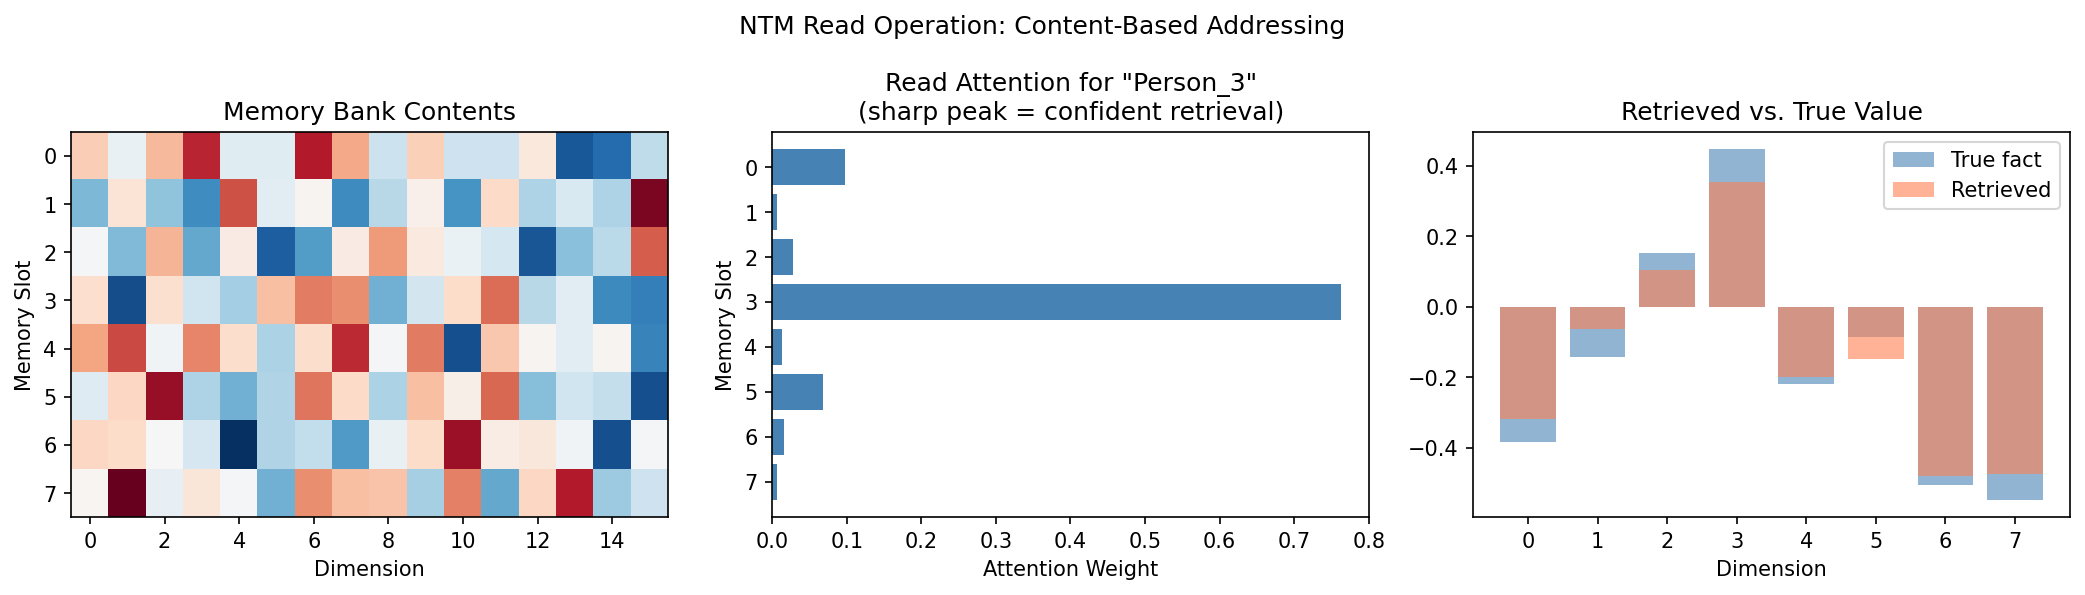

In [26]:
# Visualize the read attention for one query
# This shows HOW the NTM retrieves — by attending softly over memory slots

query_name = "Person_3"
retrieved, attention = memory.read(people_pre[query_name])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: memory bank contents
axes[0].imshow(memory.M[:memory.write_ptr], cmap='RdBu_r', aspect='auto')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Memory Slot')
axes[0].set_title('Memory Bank Contents')

# Middle: attention weights when querying for Person_3
axes[1].barh(range(memory.write_ptr), attention, color='steelblue')
axes[1].set_xlabel('Attention Weight')
axes[1].set_ylabel('Memory Slot')
axes[1].set_title(f'Read Attention for "{query_name}"\n(sharp peak = confident retrieval)')
axes[1].invert_yaxis()

# Right: retrieved value vs true value
axes[2].bar(range(val_dim), facts_pre[query_name], alpha=0.6, label='True fact', color='steelblue')
axes[2].bar(range(val_dim), retrieved, alpha=0.6, label='Retrieved', color='coral')
axes[2].set_xlabel('Dimension')
axes[2].set_title('Retrieved vs. True Value')
axes[2].legend()

plt.suptitle('NTM Read Operation: Content-Based Addressing', fontsize=12)
plt.tight_layout()
plt.show()


### Phase 2: The Lesion — Simulating H.M.'s Surgery

Now we destroy the write head. The system can no longer form new memories. But all existing memories — and the read head — remain intact.


In [27]:
# ============================================================
# LESION THE WRITE HEAD — H.M.'s surgery
# ============================================================
memory.lesion_write_head()

# Try to form NEW memories after the lesion
n_post_lesion = 4
people_post = {}
facts_post = {}

print("\n--- Attempting to form new memories after lesion ---")
for i in range(n_post_lesion):
    name = f"NewPerson_{i}"
    key = np.random.randn(key_dim); key /= np.linalg.norm(key)
    value = np.random.randn(val_dim); value /= np.linalg.norm(value)
    people_post[name] = key
    facts_post[name] = value
    success = memory.write(key, value)
    if not success:
        print(f"  Met {name} — but CANNOT store the memory")

print(f"\nMemories in bank: {memory.write_ptr}/{memory.n_slots} (unchanged!)")


⚠️  WRITE HEAD LESIONED — cannot form new memories

--- Attempting to form new memories after lesion ---
  Met NewPerson_0 — but CANNOT store the memory
  Met NewPerson_1 — but CANNOT store the memory
  Met NewPerson_2 — but CANNOT store the memory
  Met NewPerson_3 — but CANNOT store the memory

Memories in bank: 8/20 (unchanged!)


In [30]:
# ============================================================
#  What can H.M. remember?
# ============================================================

print("=== TEST 1: OLD memories (before lesion) ===\n")
old_results = []
for name, key in people_pre.items():
    retrieved, attn = memory.read(key)
    match = np.corrcoef(retrieved, facts_pre[name])[0, 1]
    old_results.append(match)
    print(f"  {name}: {'✅' if match > 0.95 else '❌'} (match: {match:.3f})")
print(f"\n  Old memory accuracy: {np.mean(old_results):.3f}")

print("\n=== TEST 2: NEW memories (after lesion) ===\n")
new_results = []
for name, key in people_post.items():
    retrieved, attn = memory.read(key)
    match = np.corrcoef(retrieved, facts_post[name])[0, 1]
    new_results.append(max(match, 0))  # clamp negatives for display
    print(f"  {name}: ❌ (match: {match:.3f}) — retrieves wrong memory!")
print(f"\n  New memory accuracy: {np.mean(new_results):.3f}")


=== TEST 1: OLD memories (before lesion) ===

  Person_0: ❌ (match: 0.934)
  Person_1: ✅ (match: 0.998)
  Person_2: ✅ (match: 0.992)
  Person_3: ✅ (match: 0.990)
  Person_4: ❌ (match: 0.896)
  Person_5: ✅ (match: 0.980)
  Person_6: ✅ (match: 0.997)
  Person_7: ❌ (match: 0.845)

  Old memory accuracy: 0.954

=== TEST 2: NEW memories (after lesion) ===

  NewPerson_0: ❌ (match: 0.115) — retrieves wrong memory!
  NewPerson_1: ❌ (match: 0.246) — retrieves wrong memory!
  NewPerson_2: ❌ (match: -0.819) — retrieves wrong memory!
  NewPerson_3: ❌ (match: -0.274) — retrieves wrong memory!

  New memory accuracy: 0.090


In [ ]:
# Visualize the dissociation
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

categories = ['Old Memories\n(before lesion)', 'New Memories\n(after lesion)']
accuracies = [np.mean(old_results), np.mean(new_results)]
axes[0].bar(categories, accuracies, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Retrieval Accuracy')
axes[0].set_title('Write-Head Lesion (H.M. Pattern)\nAnterograde Amnesia')

mem_display = memory.M.copy()
axes[1].imshow(mem_display, cmap='RdBu_r', aspect='auto')
axes[1].axhline(y=memory.write_ptr - 0.5, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Dimension'); axes[1].set_ylabel('Memory Slot')
axes[1].set_title('Memory Bank\n(red line = no entries after lesion)')

plt.tight_layout()
plt.show()

print("This is H.M.'s pattern:")
print("  • Old memories: PRESERVED (read head still works)")
print("  • New memories: CANNOT FORM (write head destroyed)")
print("  • Reasoning/language: INTACT (controller undamaged)")


### Your Turn: Read-Head Lesion (Retrograde Amnesia)

Repair the write head and lesion the *read* head instead. This simulates **retrograde amnesia** — old memories exist in the bank but can't be accessed.

1. Call `memory.repair_write_head()`
2. Call `memory.lesion_read_head()`
3. Test retrieval of old memories (should fail)
4. Write some new memories
5. Repair the read head
6. Test retrieval of the new memories (should succeed if written correctly)
7. What does this tell you about the dissociation between encoding and retrieval?


In [ ]:
# YOUR TURN: implement the read-head lesion experiment
# Use memory.repair_write_head(), memory.lesion_read_head(), etc.

# --- YOUR CODE HERE ---


In [31]:
memory.repair_write_head()

✅ Write head repaired


In [35]:
memory.lesion_read_head()
old_results = []
for name, key in people_pre.items():
    retrieved, attn = memory.read(key)
    match = np.corrcoef(retrieved, facts_pre[name])[0, 1]
    old_results.append(match)
    print(f"  {name}: {'✅' if match > 0.95 else '❌'} (match: {match:.3f})")
print(f"\n  Old memory accuracy: {np.mean(old_results):.3f}")


⚠️  READ HEAD LESIONED — cannot retrieve stored memories


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 8

### The Double Dissociation

| | Write-Head Lesion (H.M.) | Read-Head Lesion |
|---|---|---|
| **Old memories** | ✅ Preserved | ❌ Inaccessible |
| **New memories** | ❌ Cannot form | ✅ Can form |

A **double dissociation** proves that reading and writing are *functionally independent* — damaging one doesn't damage the other. This is strong evidence for distinct encoding (write) and retrieval (read) mechanisms.

> ** Discussion Question:** In real retrograde amnesia, there's often a **temporal gradient** (Ribot's Law) — recent memories are lost but very old memories are preserved. What would this look like in our model? What might it tell us about gradual transfer from hippocampus to cortex?


> ** Discussion Question:** Our model cleanly separates three things: the **read head** (retrieval mechanism), the **write head** (encoding mechanism), and the **memory bank itself** (stored content). When someone forgets something in real life, how would we ever tell whether the problem is:
>
> **(a)** A failure of the read head — the memory is still stored but the retrieval process can't find it, or
>
> **(b)** Decay of the memory trace itself — the stored content is degraded or gone, and no retrieval process could recover it?
>
> These two explanations make identical predictions in most situations: you ask for a memory and don't get it back. What experiment or observation could *distinguish* them?
>
> Some things to consider: sometimes a memory you "lost" comes back with the right cue, or under hypnosis, or when you revisit the place where you learned it — suggesting the trace was intact all along and only the retrieval failed. On the other hand, sometimes no cue in the world brings a memory back. Does that prove the trace is gone — or just that you haven't found the right key yet? Is this question even answerable in principle?


### Writing Memories That Never Happened: False Memory Injection in Mice

Our lesion study showed what happens when you *break* the write head. But what happens when you **hijack** it — forcing it to write a memory of something that never occurred?

In a landmark 2013 study, Ramirez, Liu, and Tonegawa at MIT did exactly this in mice using **optogenetics** — a technique that makes specific neurons controllable by light. Here's what they did, translated into our NTM framework:

**Day 1 (Encoding a real memory):** A mouse explores a safe room (Context A). Neurons in the dentate gyrus of the hippocampus fire, encoding a memory of this place. The researchers *tag* these specific neurons with a light-sensitive protein. In NTM terms: **the write head stores a key-value pair** — the key is "Context A," the value is "safe, nothing bad happened."

**Day 2 (Hijacking the write head):** The mouse is placed in a *different* room (Context B). While it's there, the researchers use optogenetics methods to reactivating the tagged Context A neurons in hippocampus. At that exact moment, they deliver a foot shock. The mouse's brain now binds the reactivated Context A memory (the key) to the new foot-shock experience (the value). In NTM terms: **the write head writes a false key-value pair** — the key for "Context A" gets bound to the value "painful shock," even though the shock never happened in Context A.

**Day 3 (The test):** The mouse is returned to Context A — the safe room where it was never shocked. It **freezes in fear**. It "remembers" being shocked in a place where nothing bad ever happened. The read head retrieves the false association perfectly.

This is a **manufactured misattribution** — the mouse has a genuine fear response bound to the wrong context. The memory *feels* real to the mouse. Its brain can't distinguish the optogenetically-created association from a naturally formed one.


### Schacter's Seven Sins Through the Lens of Read/Write Heads

In class, we discussed Schacter's (1999) **Seven Sins of Memory**. The NTM architecture gives us a concrete framework for reinterpreting each sin in terms of *which component fails and how*:

| Sin | Type | NTM Interpretation |
|---|---|---|
| **Transience** | Omission | Memory bank decay — stored values degrade over time, so the read head retrieves a corrupted version. Or: old slots get overwritten by new writes (catastrophic interference). |
| **Absent-mindedness** | Omission | Write head failure at encoding — the experience happened but was never written to memory. You put your keys down while thinking about something else; the write head was "busy" and didn't store the location. |
| **Blocking** | Omission | Read head retrieves the *wrong* entry — a competing key is more similar to the query than the target. the wrong name blocks the right one because its key partially matches. |
| **Misattribution** | Commission | The value is retrieved correctly but bound to the wrong key — you remember *what* happened but not *where* or *when*. The Ramirez et al. mouse experiment is a literal, experimentally-induced misattribution: a real fear response bound to the wrong context. |
| **Suggestibility** | Commission | An external source writes a false key-value pair (or overwrites an existing one). The Loftus misinformation effect: a misleading post-event suggestion gets written to the same memory slot as the original event, corrupting the stored value. |
| **Bias** | Commission | The read head applies a distorting filter — current beliefs or expectations shape what gets retrieved, like reading through tinted glasses. Or: the write head systematically encodes information in a schema-consistent way, ignoring details that don't fit. |
| **Persistence** | Commission | The read head can't *stop* retrieving a particular entry — intrusive memories, rumination, PTSD flashbacks. The key keeps matching involuntarily. There's no "suppress this slot" mechanism. |

> ** Discussion Question:** The Ramirez et al. experiment is a stunning demonstration that memory encoding is *physically manipulable* — you can force the write head to bind any key to any value. Schacter argues that each sin is the *byproduct of an otherwise adaptive system*. What adaptive feature of memory does misattribution (and suggestibility) reflect? Why would the brain build a write head that *can* be fooled?
>
> (Hint: think about flexibility.)


---
## From External Memory to Emergent Symbols

### What's Still Missing?

We've now built external memory systems that can store and retrieve key-value pairs, and we've seen how lesioning their read and write heads reproduces classic neuropsychological dissociations. The NTM is a powerful architecture — but it has a critical limitation that becomes visible when we ask a simple question:

**Can these systems learn abstract rules from just a few examples?**

Consider the concept of "same." You see two identical objects — two red circles — and judge "same." Now you see two objects you've *never encountered before* — say, two purple hexagons — and you immediately judge "same." You didn't need to be trained on purple hexagons. You extracted an abstract *rule* — "if the two things match, say same" — that applies to any objects whatsoever, including ones you've never seen.

This is **one-shot generalization of an abstract rule**: from a handful of examples, you learn something that transfers to an infinite class of new cases. It's trivially easy for humans, including young children and even some non-human primates. But it's devastatingly hard for standard neural networks.


### Why Standard Networks Fail at One-Shot Abstract Rules

A standard MLP or LSTM learns by adjusting weights over many training examples. If it has seen thousands of "red circle + red circle → same" and "blue square + green triangle → different" examples, it can learn the mapping. But its knowledge is *entangled with the specific objects it trained on*. Show it purple hexagons — objects not in its training set — and it has no basis for judgment. The network learned "these specific pixel patterns go with the label 'same,'" not the abstract rule "identity implies same."

This is not just a practical limitation — it reflects a deep **inductive bias** problem. Recall from Week 3 that an inductive bias is a built-in architectural assumption about how the world is structured:

- **ConvNets** have an inductive bias for *spatial invariance* — the same feature matters wherever it appears in an image
- **RNNs** have an inductive bias for *temporal invariance* — the same feature matters whenever it appears in a sequence
- **Standard MLPs** have essentially *no* inductive bias for abstract relational reasoning — there's nothing in the architecture that says "treat the relationship between inputs as separate from the inputs themselves"

What inductive bias would a network need to learn abstract rules like "same/different" from a few examples?


### The Variable-Binding Problem

The answer connects to one of the deepest problems in cognitive science: **variable binding** — how do we separate *roles* from *fillers*?

Consider the sentence: "The dog chased the cat." You need to know not just that "dog" and "cat" are present, but that "dog" fills the AGENT role and "cat" fills the PATIENT role. If you only stored the individual words without role-bindings, you couldn't distinguish "The dog chased the cat" from "The cat chased the dog."

A key-value memory provides exactly this: the **key** is the role (AGENT, PATIENT, SLOT_1, SLOT_2) and the **value** is the filler (dog, cat, red circle, purple hexagon). The same filler can be bound to different roles, and — crucially — the *same rule* can apply regardless of which fillers are bound.

This is what "same/different" requires:
- Bind the first object to SLOT_1
- Bind the second object to SLOT_2
- Compare: does SLOT_1 = SLOT_2?
- The answer depends only on whether the *fillers match*, not on what they are

A standard network entangles the role (slot) with the filler (object identity). An NTM *could* learn this separation because it has an external memory with distinct slots. But even an NTM has to learn the *addressing policy* — how to use its memory — from scratch, through thousands of training examples.

What if we built a network with an inductive bias that *forces* the separation of roles and fillers?


### The Emergent Symbol Binding Network (ESBN)

This is exactly what Webb et al. (2021) proposed with the **Emergent Symbol Binding Network (ESBN)**. The key idea:

**1. A standard encoder** (e.g., a CNN) processes each input image and produces a vector representation — this captures *what* the object looks like (its identity, color, shape, etc.)

**2. A learned "key generator"** maps each object's representation to a **key** in external memory — but the key is designed to capture *relational role* rather than object identity. The architecture encourages different objects to receive the *same* key if they play the same structural role.

**3. An external memory bank** stores key-value pairs, where the keys are the learned symbolic roles and the values are the object representations.

**4. A controller** reads from memory using the keys and makes decisions based on the retrieved pattern of bindings.

The inductive bias is built into the architecture: by *forcing* the network to route information through a key-value memory where keys and values are processed by different pathways, the ESBN is pressured to discover an abstract binding scheme. The keys become something like variables — abstract placeholders that can be bound to any content.

**The name "emergent symbol binding"** reflects this: the symbols (keys) aren't hand-designed — they *emerge* from training. But the architecture makes their emergence likely by providing the right structural scaffolding.

**The result:** an ESBN can learn "same/different" from just 2 training objects and generalize perfectly to 98 held-out objects it has never seen. An LSTM trained on the same data fails catastrophically on the held-out objects. The abstract rule transfers because the rule is encoded in the *keys* (which are abstract), not in the *values* (which are object-specific).

> ** Discussion Question:** The ESBN achieves one-shot generalization by building in an inductive bias that separates roles from fillers. Humans seem to come equipped with this ability from early childhood. What does this suggest about the architecture of the human mind? Is the brain more like an LSTM (general-purpose, minimal inductive bias) or more like an ESBN (structured to support variable binding)? What evidence from developmental psychology might help answer this?


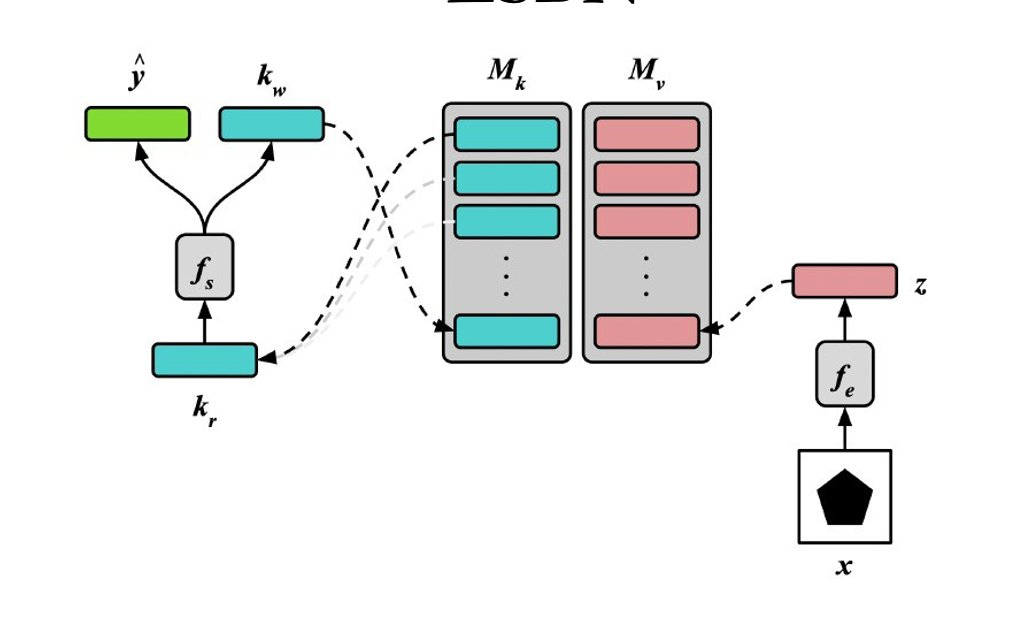

*The Emergent Symbol Binding Network (Webb et al., 2021). Two strictly separated streams: the encoder $f_e$ processes raw images into embeddings $z$ (pink, stored as values in $M_v$), while the controller $f_s$ generates abstract keys $k_w$ (teal, stored in $M_k$) and produces the output $\hat{y}$. The controller receives only retrieved keys $k_r$ — never the raw embeddings. This separation forces the controller to learn abstract, entity-independent representations.*


In [36]:
import torch.nn as nn


A closer look at the ESBN.  (<i>the following code block is just for understanding, don't execute --- some pieces have been removed for simplification) </i>.

In [ ]:
class ESBN(nn.Module):
    def __init__(self, task_gen, args):
        super(ESBN, self).__init__()

        #### 1. Bottom up- Encoder #####
        #### 2. Top-down- Controller ####

    def forward(self, x_seq, device):
        #### Encoder ####
        z_seq = []
        for x_t in x_seq:
            z_t = self.encoder(x_t)
            z_seq.append(z_t)
        z_seq = torch.stack(z_seq, dim=1)

        ## Normalize the outputs.
        if self.contextnorm:
            z_seq_all_seg = []
            for seg in range(len(self.task_seg)):
                z_seq_all_seg.append(self.apply_context_norm(z_seq[:, self.task_seg[seg], :]))
            z_seq = torch.cat(z_seq_all_seg, dim=1)

        #### Initialize hidden state ####
        hidden = torch.zeros(1, x_seq.shape[0], self.hidden_size).to(device)
        cell_state = torch.zeros(1, x_seq.shape[0], self.hidden_size).to(device)

        #### Memory model (extra time step to process key retrieved on the final time step) ####
        for t in range(x_seq.shape[1] + 1):
            # Image embedding
            if t == x_seq.shape[1]:
                z_t = torch.zeros(x_seq.shape[0], 1, self.z_size).to(device)
            else:
                z_t = z_seq[:, t, :].unsqueeze(1)

            ######### Controller #########
            #### LSTM ####
            lstm_out, (hidden, cell_state) = self.lstm(z_t, (hidden, cell_state))
            # Key output layers
            key_w = self.relu(self.key_w_out(lstm_out))
            # Gates
            g = self.sigmoid(self.g_out(lstm_out))

            # Task output layer
            y_pred_linear = self.y_out(lstm_out).squeeze()
            y_pred = y_pred_linear.argmax(1)

            #### Read from memory ####
            # Read key
            w_k = self.softmax((z_t * self.M_v).sum(dim=2))
            # How confident is the network?
            c_k = self.sigmoid(((z_t * self.M_v).sum(dim=2) * self.confidence_gain) + self.confidence_bias)
            key_r = g * (torch.cat([self.M_k, c_k.unsqueeze(2)], dim=2) * w_k.unsqueeze(2)).sum(1).unsqueeze(1)

            #### Write to memory ####
            if t == 0:
                self.M_k = key_w
                self.M_v = z_t
            else:
                self.M_k = torch.cat([self.M_k, key_w], dim=1)
                self.M_v = torch.cat([self.M_v, z_t], dim=1)

        # Return the output
        return y_pred_linear, y_pred


### <B> Let's try it!! </B>


Here, we will explore a few experimental <i> tasks </i> used by cognitive scientists, a few <i> architectures </i>, and a few <i> measurements </i> we want make as in Webb et al. (2021):

<b> Experimental Rule-Learning Tasks </b>

*   same-different judgments
*   relational match to sample (RMTS)
*   distribution of 3 - Ravens Progressive Matrices


<b> Architectures </b>

*   Long-Short Term Memory (LSTM) - a recurrent neural network with trainable input/output gates.
*   Neural Turing Machine (NTM)
*   Emergent Symbol Binding Network (ESBN)


<b> Dependent Variables (what do we want to measure?) </b>

*   How much data is required to learn? (can having an external memory save time?)
*   How well do can each architecture flexibly deal with new examples?



In [37]:
! git clone https://github.com/sfrankland/emergent_symbols.git

Cloning into 'emergent_symbols'...
remote: Enumerating objects: 355, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 355 (delta 35), reused 37 (delta 18), pack-reused 299 (from 1)
Receiving objects: 100% (355/355), 108.55 KiB | 2.09 MiB/s, done.
Resolving deltas: 100% (157/157), done.


In [38]:
pip install colorlog

### <u> Generalization Tests </u>



There are n = 100 possible unicode objects in the dataset.

We can visualize them.



In [39]:
cd emergent_symbols/

/content/emergent_symbols


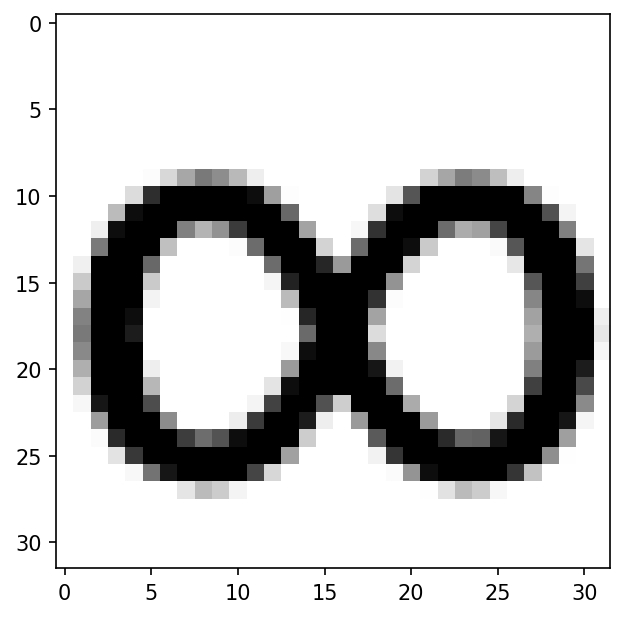

In [40]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('./imgs/89.png')
img = img[:,:,::-1]
plt.imshow(img)

holdout <i> m </i> objects from the training data.

m where 0 < <i> m </i> < <i > n - o </i>, and <i> o</i> is the minimum number of images necessary
to create a problem in a given task.

#### Model Hyperparameters

General Structure.....

!  python3 ./train_and_eval.py
  
  --model_name ESBN
  --task same_diff
  --m_holdout 98
  
  --encoder 'mlp'
  
  --epochs 10
  



##### <u> what model architecture </u>?
  --model_name

*    options: ESBN, NTM, LSTM

##### <u> what task? </u>
  --task

*     options: same_diff (Same-different judgment), RMTS (Relational-Match to Sample), dist3 (Distribution-of-3).


##### <u> what percentage of the training set should we hold out? </u>
  --m_holdout

  *     options: between 0 and 99.9. 0 means the full data set is used. 99 means only 1% is used.


##### <u> how many times should we allow it to see those examples? </u>
  --epochs


Some less important parameters
#####
--run 1

--lr

--norm_type

--device 0

### Shouldn't <b> same/different </b> judgments be easy?
Let's compare the performance using different architectures in a <b> large training data regime </b> (low generalization, m=0) and a <b> small training data regime </b> (high generalization, m=98).


this one is training lstm task


In [41]:
!  python3 ./train_and_eval.py --model_name LSTM --task same_diff --m_holdout 98 --epochs 5 --encoder 'conv' --norm_type contextnorm --lr 5e-4 --run 1 --device 0

[2026-04-23 18:00:58,644] Generating task: same_diff...
[2026-04-23 18:00:58,644] n_shapes = 100...
[2026-04-23 18:00:58,645] m_holdout = 98...
[2026-04-23 18:00:58,645] Total possible training trials = 4...
[2026-04-23 18:00:58,645] Desired training set size (10000) is larger than total number of possible training trials for this task (4)...
[2026-04-23 18:00:58,645] Changing training set size to 4...
[2026-04-23 18:00:58,646] Total possible test trials = 19012...
[2026-04-23 18:00:58,646] Test set size = 10000...
[2026-04-23 18:00:58,850] Building encoder...
[2026-04-23 18:00:58,850] Building convolutional encoder...
[2026-04-23 18:00:58,850] Conv layers...
[2026-04-23 18:00:58,868] FC layers...
[2026-04-23 18:00:58,877] Building LSTM and output layers...
[2026-04-23 18:00:58,927] Setting up optimizer...
[2026-04-23 18:01:05,642] Training begins...
[2026-04-23 18:01:06,285] [Epoch: 1] [Batch: 0 of 1] [Loss = 0.7044] [Accuracy = 75.00] [0.615 sec/batch]
[2026-04-23 18:01:06,334] [Epoc

In [45]:
!  python3 ./train_and_eval.py --model_name NTM --task same_diff --m_holdout 98 --epochs 5  --encoder 'conv' --norm_type contextnorm --lr 5e-4 --run 1 --device 0

[2026-04-23 18:03:17,547] Generating task: same_diff...
[2026-04-23 18:03:17,547] n_shapes = 100...
[2026-04-23 18:03:17,547] m_holdout = 98...
[2026-04-23 18:03:17,547] Total possible training trials = 4...
[2026-04-23 18:03:17,548] Desired training set size (10000) is larger than total number of possible training trials for this task (4)...
[2026-04-23 18:03:17,548] Changing training set size to 4...
[2026-04-23 18:03:17,548] Total possible test trials = 19012...
[2026-04-23 18:03:17,548] Test set size = 10000...
[2026-04-23 18:03:17,650] Building encoder...
[2026-04-23 18:03:17,651] Building convolutional encoder...
[2026-04-23 18:03:17,651] Conv layers...
[2026-04-23 18:03:17,653] FC layers...
[2026-04-23 18:03:17,656] Building LSTM and output layers...
[2026-04-23 18:03:17,676] Initialize memory matrix as learnable parameter...
[2026-04-23 18:03:17,695] Setting up optimizer...
[2026-04-23 18:03:23,908] Training begins...
[2026-04-23 18:03:24,086] [Epoch: 1] [Batch: 0 of 1] [Loss =

In [44]:
!  python3 ./train_and_eval.py --model_name ESBN --task same_diff  --m_holdout 98 --epochs 5 --encoder 'conv' --norm_type contextnorm --lr 5e-4 --run 1 --device 0

[2026-04-23 18:02:47,808] Generating task: same_diff...
[2026-04-23 18:02:47,809] n_shapes = 100...
[2026-04-23 18:02:47,809] m_holdout = 98...
[2026-04-23 18:02:47,809] Total possible training trials = 4...
[2026-04-23 18:02:47,809] Desired training set size (10000) is larger than total number of possible training trials for this task (4)...
[2026-04-23 18:02:47,809] Changing training set size to 4...
[2026-04-23 18:02:47,810] Total possible test trials = 19012...
[2026-04-23 18:02:47,810] Test set size = 10000...
[2026-04-23 18:02:47,937] Building encoder...
[2026-04-23 18:02:47,938] Building convolutional encoder...
[2026-04-23 18:02:47,938] Conv layers...
[2026-04-23 18:02:47,939] FC layers...
[2026-04-23 18:02:47,943] Building LSTM and output layers...
[2026-04-23 18:02:47,971] Setting up optimizer...
[2026-04-23 18:02:55,148] Training begins...
[2026-04-23 18:02:55,360] [Epoch: 1] [Batch: 0 of 1] [Loss = 0.6923] [Accuracy = 50.00] [0.210 sec/batch]
[2026-04-23 18:02:55,504] [Epoc



**putting the blocks into 3 separate, to use LSTM, ESBN, N__ all separate**



In [55]:
from numpy import genfromtxt
#how many epochs to load?
max_epochs = 2
#initialize a large empty array
ESBN_all_epochs = np.empty([max_epochs*1000, 3])
#loop over epochs
for j in range(max_epochs):
  #define file location and name to read
  #pay attention to model name (e.g., ESBN) m, and task. these will be stored in separate folders.
  test_fname = '/content/emergent_symbols/train_prog/same_diff/m98/ESBN_contextnorm_lr0.0005/epoch_' + str(j+1) + '.txt'
  print('reading epoch_' + str(j+1))

  this_epoch = genfromtxt(test_fname, delimiter=',', skip_header=1, usecols = (0, 1, 2))

  #concatenate with preceding.
  ESBN_all_epochs = np.concatenate((this_epoch, ESBN_all_epochs))

reading epoch_1


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [63]:
from numpy import genfromtxt

max_epochs = 5
all_data = []

for j in range(max_epochs):
    test_fname = '/content/emergent_symbols/train_prog/same_diff/m98/ESBN_contextnorm_lr0.0005/epoch_' + str(j+1) + '.txt'
    print('reading epoch_' + str(j+1))
    this_epoch = genfromtxt(test_fname, delimiter=',', skip_header=1, usecols=(0, 1, 2))
    all_data.append(this_epoch)

ESBN_all_epochs = np.concatenate(all_data, axis=0)

reading epoch_1
reading epoch_2
reading epoch_3
reading epoch_4
reading epoch_5


In [70]:
from numpy import genfromtxt

max_epochs = 5
all_data = []

for j in range(max_epochs):
    test_fname = './train_prog/same_diff/m98/NTM_contextnorm_lr0.0005/epoch_' + str(j+1) + '.txt'
    print('reading epoch_' + str(j+1))
    this_epoch = genfromtxt(test_fname, delimiter=',', skip_header=1, usecols=(0, 1, 2))
    all_data.append(this_epoch)

NTM_all_epochs = np.concatenate(all_data, axis=0)

reading epoch_1
reading epoch_2
reading epoch_3
reading epoch_4
reading epoch_5


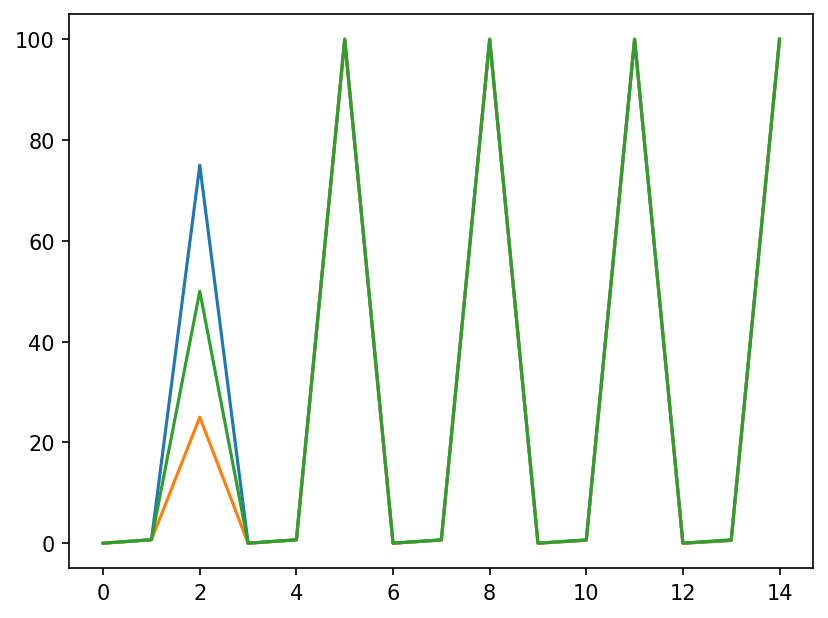

In [75]:
plt.plot(LSTM_all_epochs)
plt.plot(NTM_all_epochs)
plt.plot(ESBN_all_epochs)

Plot the heldout test data for each trained model. How well can each model generalize it's knowledge to new objects?

In [ ]:
  #define file location and name to read
  test_fname = './test/same_diff/m0/NTM_contextnorm_lr0.0005/run1' + str(j+1) + '.txt'
  print('reading epoch_' + str(j+1))

reading epoch_2


#### <b> Relational Match-to-Sample (RMTS) </b>

Same/different judgments, but on  <i> relations </i> between objects. (i.e., higher order same/different judgments).

Some cognitive scientists have argued that this ability to perform this task is unique to humans, relative to other primate species, making it an important test of intelligence.

Long Short Term Memory (LSTM) / RMTS

In [ ]:
!  python3 ./train_and_eval.py --model_name LSTM --task rmts --m_holdout 90 --epochs 5 --encoder 'conv' --norm_type contextnorm --lr 5e-4  --run 1 --device 0

Neural Turing Machine (NTM) / RMTS

In [ ]:
!  python3 ./train_and_eval.py --model_name NTM --task rmts --m_holdout 90 --epochs 5 --encoder 'conv' --norm_type contextnorm --lr 5e-4  --run 1 --device 0

Emergent Symbol Binding Network (ESBN) / RMTS

In [ ]:
!  python3 ./train_and_eval.py --model_name ESBN --task rmts --m_holdout 90 --epochs 5 --encoder 'conv' --norm_type contextnorm --lr 5e-4  --run 1 --device 0

#### <b> "Distribution of 3" </b> (Raven's Progressive Matrices)

Raven’s Progressive Matrices (RPM; Raven & Court (1938)) is a commonly used visual problem-solving task, and is one of the most widely used tests of fluid intelligence, the ability to reason and make inferences in a novel domain
(as opposed to crystallized intelligence, the ability to solve familiar tasks).

A 3x3 array of elements is presented, with the lower right element of the array left blank. The task is to infer the rule that governs the elements in the array, and then use that rule to select from among 8 candidate completions.

For distribution of 3, the same set of three elements (e.g. a triangle, square, and circle) will appear in each row, though the order doesn’t matter. The task in this case is simply to identify the set, determining which element is missing from the final row.

Long Short Term Memory / dist_3

In [ ]:
!  python3 ./train_and_eval.py --model_name LSTM --task dist3 --m_holdout 90 --epochs 5  --encoder 'conv' --norm_type contextnorm --lr 5e-4  --run 1 --device 0

Neural Turing Machine / dist_3

In [ ]:
!  python3 ./train_and_eval.py --model_name NTM --task dist_3 --m_holdout 90 --epochs 5 --run 1 --device 0 --encoder 'conv' --norm_type contextnorm --lr 5e-4

Emergent Symbol Binding Network / dist_3

In [ ]:
!  python3 ./train_and_eval.py --model_name ESBN --task dist_3 --m_holdout 90 --epochs 5 --run 1 --device 0 -encoder 'conv' --norm_type contextnorm --lr 5e-4 --task dist3

---
## Appendix: Do These Inductive Biases Help with Everything?

### Testing the ESBN on Catastrophic Interference

Throughout this course, we've seen that **inductive biases** — architectural assumptions about problem structure — can be powerful. ConvNets assume spatial invariance. RNNs assume temporal invariance. The ESBN assumes that tasks have separable roles and fillers, connected through a key-value memory.

But inductive biases are *bets* about the world. They help enormously when the bet is right (the ESBN on same/different: near-perfect generalization from 2 training objects). But what happens when the bet is wrong?

Let's test this with the **add-1 / add-2 catastrophic interference** task from Week 3. This task requires producing a *specific output code* for each input — it's not a relational task. The ESBN's strict separation of controller from content was designed for relational reasoning, not content-specific mappings.

**Prediction:** The MLP should learn each task well but catastrophically forget when the task switches. The ESBN, with its strict separation, might resist forgetting — but it might also struggle to learn the task *at all*, because its inductive bias is wrong for this problem.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random

# ============================================================
# SET UP THE ADD-1 / ADD-2 TASK (same as Week 3)
# ============================================================
S = 20
max_int = 50
k = np.random.randint(2, size=(max_int, S)).astype(np.float32)

ones_x = np.empty([max_int, S*2 + 4], dtype=np.float32)
ones_y = np.empty([max_int, S], dtype=np.float32)
twos_x = np.empty([max_int, S*2 + 4], dtype=np.float32)
twos_y = np.empty([max_int, S], dtype=np.float32)

for i in range(max_int - 2):
    ones_x[i] = np.concatenate((k[i], k[0], [1, 0, 0, 1]))
    twos_x[i] = np.concatenate((k[i], k[1], [0, 1, 1, 0]))
    ones_y[i] = k[i+1]
    twos_y[i] = k[i+2]

n_train = 10
ones_loader = DataLoader(TensorDataset(
    torch.tensor(ones_x[:n_train]), torch.tensor(ones_y[:n_train])))
twos_loader = DataLoader(TensorDataset(
    torch.tensor(twos_x[:n_train]), torch.tensor(twos_y[:n_train])))


In [ ]:
# ============================================================
# MODEL 1: SIMPLE MLP (no external memory)
# ============================================================
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim))
    def forward(self, x):
        return self.net(x)

# ============================================================
# MODEL 2: STRICT ESBN (controller NEVER sees raw input)
# ============================================================
# This is the original ESBN design: the controller only receives
# retrieved keys, and the output comes entirely from the controller.
# NO skip connection from encoder to output.

class StrictESBN(nn.Module):
    def __init__(self, input_dim, embed_dim, key_dim, output_dim, n_slots=200):
        super().__init__()
        self.embed_dim = embed_dim
        self.key_dim = key_dim
        self.n_slots = n_slots

        # Stream 1: Encoder (raw input -> embedding, stored as VALUE)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim))

        # Gate (separate from controller)
        self.gate_net = nn.Sequential(
            nn.Linear(key_dim + 1, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid())

        # Stream 2: Controller (ONLY sees retrieved keys — never the embedding)
        self.controller = nn.Sequential(
            nn.Linear(key_dim + 1, key_dim), nn.ReLU(),
            nn.Linear(key_dim, key_dim), nn.ReLU())

        self.write_key_head = nn.Linear(key_dim, key_dim)

        # Output comes ONLY from controller — strict separation
        self.output_head = nn.Linear(key_dim, output_dim)

        self.conf_gain = nn.Parameter(torch.ones(1))
        self.conf_bias = nn.Parameter(torch.zeros(1))

        self.Mk = torch.zeros(n_slots, key_dim)
        self.Mv = torch.zeros(n_slots, embed_dim)
        self.n_written = 0

    def reset_memory(self):
        self.Mk = torch.zeros(self.n_slots, self.key_dim)
        self.Mv = torch.zeros(self.n_slots, self.embed_dim)
        self.n_written = 0

    def forward(self, x):
        squeeze = x.dim() == 1
        if squeeze: x = x.unsqueeze(0)
        batch = x.shape[0]

        z = self.encoder(x)

        if self.n_written > 0:
            stored_v = self.Mv[:self.n_written].clone()
            sim = torch.mm(z, stored_v.t())
            wk = torch.softmax(sim, dim=-1)
            conf = torch.sigmoid(self.conf_gain * sim.max(-1, keepdim=True)[0] + self.conf_bias)
            stored_k = self.Mk[:self.n_written].clone()
            kr = torch.mm(wk, stored_k)
            gate = self.gate_net(torch.cat([kr, conf], dim=-1))
            ctrl_in = torch.cat([kr * gate, conf], dim=-1)
        else:
            ctrl_in = torch.zeros(batch, self.key_dim + 1)

        h = self.controller(ctrl_in)
        kw = self.write_key_head(h)

        if self.training and self.n_written < self.n_slots:
            self.Mk[self.n_written] = kw.mean(0).detach()
            self.Mv[self.n_written] = z.mean(0).detach()
            self.n_written += 1

        # Output from controller ONLY — no access to the embedding
        out = self.output_head(h)
        if squeeze: out = out.squeeze(0)
        return out

print("Models defined: SimpleMLP and StrictESBN")


In [ ]:
# ============================================================
# SEQUENTIAL TRAINING: ADD 1 → ADD 2
# ============================================================

input_dim = S*2 + 4
hidden_dim = 100
output_dim = S
L1 = nn.L1Loss()
all_epochs = 4000
eval_every = 20

def evaluate(model, loader):
    model.eval()
    total = sum(L1(model(x), y).item() for x, y in loader) / len(loader)
    model.train()
    return total

# --- MLP ---
mlp = SimpleMLP(input_dim, hidden_dim, output_dim)
mlp_opt = optim.SGD(mlp.parameters(), lr=0.01)
mlp_ones, mlp_twos = [], []

print("Training MLP...")
for epoch in range(all_epochs):
    mlp.train()
    for x, y in (ones_loader if epoch < all_epochs//2 else twos_loader):
        mlp_opt.zero_grad()
        loss = L1(mlp(x), y); loss.backward()
        nn.utils.clip_grad_norm_(mlp.parameters(), 1.0); mlp_opt.step()
    if epoch % eval_every == 0:
        mlp_ones.append(evaluate(mlp, ones_loader))
        mlp_twos.append(evaluate(mlp, twos_loader))
    if epoch % 1000 == 0: print(f"  epoch {epoch}")
print("  Done!")

# --- Strict ESBN ---
esbn = StrictESBN(input_dim, embed_dim=64, key_dim=32, output_dim=output_dim)
esbn_opt = optim.Adam(esbn.parameters(), lr=5e-4)
esbn_ones, esbn_twos = [], []

print("\nTraining Strict ESBN...")
for epoch in range(all_epochs):
    esbn.train()
    for x, y in (ones_loader if epoch < all_epochs//2 else twos_loader):
        esbn_opt.zero_grad()
        loss = L1(esbn(x), y); loss.backward()
        nn.utils.clip_grad_norm_(esbn.parameters(), 1.0); esbn_opt.step()
    if epoch % eval_every == 0:
        esbn_ones.append(evaluate(esbn, ones_loader))
        esbn_twos.append(evaluate(esbn, twos_loader))
    if epoch % 1000 == 0: print(f"  epoch {epoch}")
print("  Done!")


In [ ]:
# ============================================================
# COMPARE
# ============================================================
epochs_plot = np.arange(0, all_epochs, eval_every)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(epochs_plot, mlp_ones, label='Add 1', color='steelblue')
axes[0].plot(epochs_plot, mlp_twos, label='Add 2', color='coral')
axes[0].axvline(x=all_epochs//2, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Error')
axes[0].set_title('MLP (No External Memory)\nLearns well, forgets catastrophically')
axes[0].legend()

axes[1].plot(epochs_plot, esbn_ones, label='Add 1', color='steelblue')
axes[1].plot(epochs_plot, esbn_twos, label='Add 2', color='coral')
axes[1].axvline(x=all_epochs//2, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_title('Strict ESBN (Controller only sees keys)\nResists forgetting, but struggles to learn')
axes[1].legend()

plt.suptitle('The Inductive Bias Tradeoff: Add 1 → Add 2', fontsize=13)
plt.tight_layout()
plt.show()


### The Lesson: Inductive Biases Are Bets

Compare the two panels:

**The MLP** learns each task to near-zero error — but catastrophically forgets add-1 when it switches to add-2. It has no inductive bias protecting it from interference, but it also has no inductive bias *preventing* it from learning any particular task.

**The Strict ESBN** may resist catastrophic forgetting — but it also struggles to drive error down on either task. The strict separation between controller and content, which was so powerful for same/different generalization (near-perfect from 2 training examples!), actively *hurts* on a task where the correct output depends on specific content.

This is the fundamental tradeoff:

| | MLP | ESBN |
|---|---|---|
| **Inductive bias** | None (general-purpose) | Strict role/filler separation |
| **Same/different** (relational) | ❌ Fails to generalize | ✅ Perfect generalization |
| **Add-1/Add-2** (content-specific) | ✅ Learns perfectly | ❌ Struggles to learn |
| **Catastrophic forgetting** | ❌ Severe | ✅ Resistant |

**There is no free lunch.** An architecture that's perfect for relational reasoning may be terrible for content-specific tasks, and vice versa. This is why the brain likely has *multiple* specialized systems rather than one general-purpose architecture — different computational problems require different inductive biases.

> **Discussion Question:** The brain seems to handle *both* relational reasoning ("these two things are the same") and content-specific memory ("the capital of France is Paris") — tasks that require opposite inductive biases. How might the brain achieve this? Does it use different systems for different types of problems? If so, how does it decide which system to use for a given task?

